# 1. 라이브러리/데이터 불러오기

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, NullFormatter
from scipy.stats import binomtest, chi2_contingency, ks_2samp, mannwhitneyu, false_discovery_control
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedGroupKFold
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# 한글 폰트 / 마이너스 부호 깨짐 방지: 윈도우(맑은 고딕) / 맥(AppleGothic) / 리눅스(나눔고딕) 중 설치된 것 사용
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams['font.family'] = next((f for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic'] if f in installed_fonts),
                                   'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)

SEED = 42  # 난수 시드 (전체 공통)

In [2]:
DATA_DIR = Path('data')

# 첫 번째 컬럼(이름 없음)은 원본 인덱스
labeled = pd.read_csv(DATA_DIR / 'moldset_labeled_cn7.csv', index_col=0)
unlabeled = pd.read_csv(DATA_DIR / 'moldset_unlabeled_cn7.csv', index_col=0)

print('labeled  :', labeled.shape)
print('unlabeled:', unlabeled.shape)

labeled  : (1211, 25)
unlabeled: (35239, 24)


In [3]:
labeled.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,1.679123,1.491397,-0.478017,0.361047,0.97858,-0.711164,1.532018,0.0,-1.152398,-0.795730,-0.132022,0.63521,1.256518,-0.916676,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574
1,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,-1.347095,0.049553,-0.132022,0.63521,1.573231,-0.740752,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,-1.347095,0.049553,-0.132022,0.63521,1.573231,-0.740752,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,-1.347095,1.740153,-0.132022,0.63521,1.256518,-0.740752,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,-1.347095,1.740153,-0.132022,0.63521,1.256518,-0.740752,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339


In [4]:
unlabeled.head()

,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
114610,1.346829,-2.768862,0.961909,1.843294,1.029767,1.031111,0.849819,0.861854,2.489188,1.025136,1.031548,0.494886,0.345152,0.183351,0.221579,1.015093,0.919876,0.846380,0.637023,2.099671,1.025241,-0.551566,0.756435,0.600810
114688,1.360046,-2.720306,0.963280,1.847956,1.029767,1.031048,0.863559,0.861854,2.446877,1.025136,1.031548,0.497896,0.348230,0.201286,0.228419,1.020221,0.988615,0.874453,0.703109,2.099671,1.074495,-0.503460,0.818567,0.700620
114919,1.355641,-2.720306,0.966020,1.843294,1.029767,1.031080,0.864246,0.861854,2.446877,1.025136,1.031548,0.497896,0.351308,0.171395,0.221579,1.014360,0.862594,0.874453,0.637023,2.293882,0.975987,-0.599672,0.694303,0.574194
115304,1.360046,-2.720306,0.960539,1.843294,1.029767,1.031143,0.864246,0.861854,2.455339,1.025136,1.031548,0.497896,0.332839,0.183351,0.221579,1.017290,0.919876,0.944634,0.785717,2.099671,1.058077,-0.599672,0.531206,0.394536
115582,1.360046,-2.720306,0.967391,1.847956,1.029767,1.031048,0.864933,0.861854,2.446877,1.018644,1.031548,0.497896,0.326683,0.165417,0.221579,1.018756,0.851137,0.916562,0.670066,2.177355,0.992405,-0.599672,0.585571,0.434460


In [5]:
# 라벨 분포 및 결측치 확인
print(labeled['PassOrFail'].value_counts())
print()
print('결측치 - labeled:', labeled.isna().sum().sum(), '/ unlabeled:', unlabeled.isna().sum().sum())

PassOrFail
0    1194
1      17
Name: count, dtype: int64

결측치 - labeled: 0 / unlabeled: 0


# 2. 데이터 종류 및 개수 확인

### 2-1. 컬럼 / 데이터 타입

In [6]:
labeled.info()

<class 'pandas.DataFrame'>
RangeIndex: 1211 entries, 0 to 1210
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PassOrFail                1211 non-null   int64  
 1   Injection_Time            1211 non-null   float64
 2   Filling_Time              1211 non-null   float64
 3   Plasticizing_Time         1211 non-null   float64
 4   Cycle_Time                1211 non-null   float64
 5   Clamp_Close_Time          1211 non-null   float64
 6   Cushion_Position          1211 non-null   float64
 7   Plasticizing_Position     1211 non-null   float64
 8   Clamp_Open_Position       1211 non-null   float64
 9   Max_Injection_Speed       1211 non-null   float64
 10  Max_Screw_RPM             1211 non-null   float64
 11  Average_Screw_RPM         1211 non-null   float64
 12  Max_Injection_Pressure    1211 non-null   float64
 13  Max_Switch_Over_Pressure  1211 non-null   float64
 14  Max_Back_Pressure  

In [7]:
unlabeled.info()

<class 'pandas.DataFrame'>
Index: 35239 entries, 114610 to 777220
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            35239 non-null  float64
 1   Filling_Time              35239 non-null  float64
 2   Plasticizing_Time         35239 non-null  float64
 3   Cycle_Time                35239 non-null  float64
 4   Clamp_Close_Time          35239 non-null  float64
 5   Cushion_Position          35239 non-null  float64
 6   Plasticizing_Position     35239 non-null  float64
 7   Clamp_Open_Position       35239 non-null  float64
 8   Max_Injection_Speed       35239 non-null  float64
 9   Max_Screw_RPM             35239 non-null  float64
 10  Average_Screw_RPM         35239 non-null  float64
 11  Max_Injection_Pressure    35239 non-null  float64
 12  Max_Switch_Over_Pressure  35239 non-null  float64
 13  Max_Back_Pressure         35239 non-null  float64
 14  Average_Back_Pre

In [8]:
TARGET = 'PassOrFail'
FEATURES = [c for c in labeled.columns if c != TARGET]

print('피처 수:', len(FEATURES))
print('unlabeled와 피처 컬럼 동일:', FEATURES == list(unlabeled.columns))

피처 수: 24
unlabeled와 피처 컬럼 동일: True


### 2-2. 컬럼별 고유값 개수

In [9]:
nunique = pd.DataFrame({
    'labeled': labeled[FEATURES].nunique(),
    'unlabeled': unlabeled[FEATURES].nunique(),
}).sort_values('labeled')
nunique

,labeled,unlabeled
Clamp_Open_Position,1,47
Clamp_Close_Time,3,69
Cushion_Position,5,85
Average_Screw_RPM,7,50
Max_Screw_RPM,8,21
Max_Injection_Pressure,8,179
Plasticizing_Position,13,169
Cycle_Time,13,251
Barrel_Temperature_6,13,81
Filling_Time,14,124


In [10]:
# labeled에서 값이 하나뿐인 상수 컬럼
const_cols = nunique.index[nunique['labeled'] == 1].tolist()
const_cols

['Clamp_Open_Position']

### 2-3. 라벨(PassOrFail) 개수 / 비율

In [11]:
label_cnt = pd.DataFrame({
    'count': labeled[TARGET].value_counts(),
    'ratio(%)': (labeled[TARGET].value_counts(normalize=True) * 100).round(2),
})
label_cnt

,count,ratio(%)
PassOrFail,,
0,1194,98.6
1,17,1.4


### 2-4. 중복 데이터 확인

In [12]:
print('전체 행 중복 - labeled  :', labeled.duplicated().sum(), '/', len(labeled))
print('전체 행 중복 - unlabeled:', unlabeled.duplicated().sum(), '/', len(unlabeled))
print('피처만 중복 - labeled  :', labeled[FEATURES].duplicated().sum(), '/', len(labeled))

전체 행 중복 - labeled  : 594 / 1211
전체 행 중복 - unlabeled: 6468 / 35239
피처만 중복 - labeled  : 605 / 1211


In [13]:
# 피처가 완전히 같은데 라벨이 다른 경우
fail = labeled[labeled[TARGET] == 1]
ok = labeled[labeled[TARGET] == 0]

twin = (fail.reset_index()
        .merge(ok.reset_index(), on=FEATURES, suffixes=('_fail', '_pass'))
        [['index_fail', 'index_pass']])

print('불량 중 동일 피처의 양품이 있는 개수:', twin['index_fail'].nunique(), '/', len(fail))
twin.head(10)

불량 중 동일 피처의 양품이 있는 개수: 11 / 17


,index_fail,index_pass
0,47,48
1,80,79
2,95,96
3,99,100
4,101,102
5,103,104
6,105,106
7,107,108
8,109,110
9,111,112


In [14]:
# 인덱스 범위 / 연속성
for name, df in [('labeled', labeled), ('unlabeled', unlabeled)]:
    idx = df.index.to_series()
    print(f'{name:9s}: {idx.min()} ~ {idx.max()}, 연속={(idx.diff().dropna() == 1).all()}')

print('labeled / unlabeled 인덱스 겹침:', len(labeled.index.intersection(unlabeled.index)))

labeled  : 0 ~ 1210, 연속=True
unlabeled: 114610 ~ 777220, 연속=False
labeled / unlabeled 인덱스 겹침: 0


# 3. 데이터 정제(전처리)

- **unlabeled → 학습용**: 중복 / 센서 오류 / 누수 구간 / 다른 운전 조건을 걸러 "labeled와 같은 조건의 정상 패턴"만 남긴다.
- **labeled → 평가용**: unlabeled 스케일로 역변환하고, 한 샷에서 나온 부품 쌍은 모두 남긴 채 쌍 순서(`pair_pos`)를 붙인다.

> 두 파일은 각자 따로 표준화되어 있어서(평균 0, 표준편차 1) 그대로는 같이 쓸 수 없다. 역변환은 3-4에서 한다.

### 3-1. 사용 피처 정의 (상수 컬럼 제거)

In [15]:
# labeled에서 값이 하나뿐인 Clamp_Open_Position은 원래 값을 복원할 수 없으므로 제외
FEATS = [c for c in FEATURES if c not in const_cols]
print('제외:', const_cols)
print('사용 피처 수:', len(FEATS))

제외: ['Clamp_Open_Position']
사용 피처 수: 23


### 3-2. unlabeled 연속 중복 행 제거

바로 앞 행과 공정 값이 완전히 같은 행은 **같은 샷의 두 번째 기록**이다 (한 샷에서 부품 2개가 나오고 두 부품은 공정 값이 같다 — 3-7 참고).
unlabeled는 라벨이 없어 부품을 구분할 이유가 없고, 공정 값의 정상 패턴을 배우는 데는 샷당 한 번이면 충분하므로 하나만 남긴다.

In [16]:
# 바로 앞 행과 값이 완전히 같은 행 = 같은 샷의 두 번째 기록
is_dup = unlabeled.eq(unlabeled.shift()).all(axis=1)
unl = unlabeled[~is_dup]
print(f'{len(unlabeled)} → {len(unl)}  (중복 {is_dup.sum()}행 제거)')

35239 → 28772  (중복 6467행 제거)


### 3-3. 센서 오류 제거

In [17]:
# 물리적으로 불가능한 값 확인: RG3에서는 Max_Switch_Over_Pressure가 z=121로 튄 행이 있었다 (나머지 최댓값 0.9 수준)
max_abs_z = unl[FEATS].abs().max(axis=1)
print(max_abs_z.nlargest(3))

sensor_err = max_abs_z > 50
unl = unl[~sensor_err]
print()
print(f'센서 오류 {sensor_err.sum()}행 제거 → {len(unl)}')

607402    7.252195
607405    6.928488
669929    5.229030
dtype: float64

센서 오류 0행 제거 → 28772


### 3-4. labeled 역변환 (unlabeled 스케일로 맞추기)

컬럼마다 `z_unlabeled = a · z_labeled + b` 관계가 성립한다.

- **a** : 센서 값은 일정한 눈금(예: 0.1 단위)으로 기록된다 → 두 파일의 눈금 간격 비율로 후보를 구한다.
- **b** : labeled 값을 옮겼을 때 모두 unlabeled 눈금 위에 떨어지는 값들이 후보다.
- CN7은 labeled에만 있는 극단값(`Plasticizing_Time` z≈20, 마지막 샷)이 있어 "전부"를 만족하는 후보가 없는 컬럼이 생긴다. 이때만 **눈금 위에 떨어지는 값이 가장 많은 후보**로 대신한다 (전부 맞는 후보가 있으면 RG3와 동일). 대신한 컬럼은 3-4 표의 `눈금 밖 행`으로 확인한다.
- 후보가 여러 개이므로, **변환한 labeled 행이 unlabeled에 실제로 있는 행과 23개 값 모두 일치하는 개수**가 최대가 되는 조합을 고른다 (빔 서치).

In [18]:
def min_step(values):
    """정렬된 고유값 사이의 최소 간격 = 눈금 간격"""
    d = np.diff(np.sort(np.unique(values)))
    return d[d > 1e-9].min()


def grid_codes(grid, x):
    """x를 grid(정렬된 고유값)에서 가장 가까운 눈금 번호로 바꾼다"""
    idx = np.clip(np.searchsorted(grid, x), 1, len(grid) - 1)
    left_closer = np.abs(grid[idx - 1] - x) <= np.abs(grid[idx] - x)
    return np.where(left_closer, idx - 1, idx)


def column_candidates(lab, unl_col, max_k=5):
    """한 컬럼에서 가능한 (a, b) 후보: 변환한 labeled 값이 전부 unlabeled 눈금 위에 떨어지는 경우.
    그런 후보가 없으면(labeled에만 있는 값이 있을 때) 눈금 위에 떨어지는 값이 가장 많은 후보들"""
    grid = np.sort(unl_col.unique())
    lv = np.sort(lab.unique())
    su, sl = min_step(grid), min_step(lv)
    tol = su * 0.05
    cands = []
    for k in range(1, max_k + 1):  # labeled 최소 간격이 원래 눈금의 k배일 수 있음
        a = su * k / sl
        if a * (lv.max() - lv.min()) > grid.max() - grid.min():
            continue
        for g0 in grid:  # labeled 최솟값이 어느 눈금에 대응하는지
            b = g0 - a * lv.min()
            t = a * lab.values + b
            if t.max() > grid.max() + tol:
                break
            code = grid_codes(grid, t)
            n_on = int((np.abs(grid[code] - t) < tol).sum())
            cands.append({'a': a, 'b': b, 'code': code.astype(np.uint64), 'n_on': n_on})
    n_best = max(c['n_on'] for c in cands)
    return [c for c in cands if c['n_on'] == n_best]

In [19]:
%%time
L = labeled[FEATS].drop_duplicates()
U = unl[FEATS].drop_duplicates()

cands = {c: column_candidates(L[c], U[c]) for c in FEATS}
u_code = {c: grid_codes(np.sort(U[c].unique()), U[c].values).astype(np.uint64) for c in FEATS}

# 여러 컬럼 값 조합을 해시 하나로 묶어 빠르게 비교
rng = np.random.default_rng(SEED)
W = {c: np.uint64(rng.integers(1, 2**63)) for c in FEATS}


def row_hash(codes):
    h = 0
    with np.errstate(over='ignore'):
        for c, code in codes.items():
            h = h + code * W[c]
    return h


def match_count(choice):
    """choice = {컬럼: 후보 번호} → 변환한 labeled 행 중 unlabeled에 똑같은 행이 있는 개수"""
    lh = row_hash({c: cands[c][i]['code'] for c, i in choice.items()})
    uh = row_hash({c: u_code[c] for c in choice})
    return np.isin(lh, uh).sum()


# 후보가 적은 컬럼부터 하나씩 추가하며 상위 조합만 유지
beam = [{}]
for c in sorted(FEATS, key=lambda c: len(cands[c])):
    scored = [(match_count({**ch, c: i}), {**ch, c: i}) for ch in beam for i in range(len(cands[c]))]
    scored.sort(key=lambda x: -x[0])
    beam = [ch for _, ch in scored[:5]]
best = beam[0]
print('일치하는 labeled 고유 행:', match_count(best), '/', len(L))

일치하는 labeled 고유 행: 606 / 606
CPU times: total: 16.6 s
Wall time: 16.8 s


In [20]:
# 컬럼별 확인: 다른 컬럼은 고정하고 이 컬럼만 다른 후보로 바꿨을 때 점수가 얼마나 떨어지는지
rows = []
for c in FEATS:
    scores = [match_count({**best, c: i}) for i in range(len(cands[c]))]
    second = max([s for i, s in enumerate(scores) if i != best[c]], default=np.nan)
    rows.append({'col': c, 'a': cands[c][best[c]]['a'], 'b': cands[c][best[c]]['b'],
                 '후보수': len(cands[c]), '눈금 밖 행': len(L) - cands[c][best[c]]['n_on'],
                 '1등': scores[best[c]], '2등': second})
coef = pd.DataFrame(rows).set_index('col')

Path('outputs/tables').mkdir(parents=True, exist_ok=True)
coef[['a', 'b']].rename_axis('feature').to_csv('outputs/tables/inverse_transform_coef.csv', encoding='utf-8-sig')
coef

,a,b,후보수,눈금 밖 행,1등,2등
col,,,,,,
Injection_Time,0.010981,1.064058,41,0,606,124.0
Filling_Time,0.040167,-0.562812,35,0,606,93.0
Plasticizing_Time,0.027924,0.988962,1,1,606,NaN
Cycle_Time,0.003057,0.853880,3,0,606,0.0
Clamp_Close_Time,0.002643,1.042097,89,0,606,325.0
Cushion_Position,0.000017,1.030179,41,0,606,381.0
Plasticizing_Position,0.011381,1.063932,1,0,606,NaN
Max_Injection_Speed,0.043465,0.906064,25,0,606,0.0
Max_Screw_RPM,0.007679,1.031246,5,0,606,0.0


> 1등과 2등의 점수 차이가 작은 컬럼이 있는지 확인한다 (RG3에서는 22개가 확정적, `Injection_Time`만 1·2등이 비슷했으나 차이가 눈금 한 칸이라 무시).

→ 23개 컬럼 모두 1등(606)과 2등(최대 381)의 점수 차이가 커서 확정적이다. `Plasticizing_Time`·`Plasticizing_Position`은 후보가 1개뿐이다.
`Plasticizing_Time`의 `눈금 밖 행` 1은 마지막 샷(idx 1209·1210)의 z≈20 값으로, unlabeled에 같은 값이 없어 가장 가까운 눈금으로 대응했다.

In [21]:
# 역변환 적용
lab = labeled.copy()
for c in FEATS:
    lab[c] = coef.loc[c, 'a'] * labeled[c] + coef.loc[c, 'b']
lab = lab[FEATS + [TARGET]]

# 검증: unlabeled 값 범위를 벗어나는 labeled 행 수 (변환 전 vs 후)
def out_of_range(df):
    return ((df[FEATS] < unl[FEATS].min() - 1e-6) | (df[FEATS] > unl[FEATS].max() + 1e-6)).any(axis=1).sum()

print('unlabeled 범위 밖 labeled 행: 변환 전', out_of_range(labeled), '→ 변환 후', out_of_range(lab))

unlabeled 범위 밖 labeled 행: 변환 전 1087 → 변환 후 2


### 3-5. 누수 구간 제거

역변환한 labeled 행이 **unlabeled의 한 구간 행과 23개 값 모두 일치**하고 순서도 같다면, labeled는 unlabeled와 같은 원본의 **같은 기간**에서 나온 것이다 (RG3: 1,182행 중 774행 일치).
이 구간을 학습에 쓰면 평가할 샷(불량 포함)을 모델이 미리 보게 된다.
바로 옆 샷도 값이 거의 같아서 일치한 행만 빼면 누수가 남으므로, **구간을 통째로** 뺀다.

→ CN7은 **labeled 1,211행 전부**(불량 17개 포함)가 unlabeled idx 751091~777219 구간과 23개 값 모두 일치하고 순서도 같다 (spearman 1.0).
RG3(1,182행 중 774행)와 달리 labeled 전체가 unlabeled 안에 들어 있다. 이 구간 8,135행을 빼면 unlabeled는 20,637행이 남는다.

In [22]:
def to_grid(df):
    """각 값을 unlabeled 눈금 번호로 바꾼 표 (행끼리 정확히 비교하기 위함)"""
    return pd.DataFrame({c: grid_codes(np.sort(unl[c].unique()), df[c].values) for c in FEATS}, index=df.index)

pairs = (to_grid(lab).reset_index(names='lab_idx')
         .merge(to_grid(unl).reset_index(names='unl_idx'), on=FEATS))[['lab_idx', 'unl_idx']]

matched = pairs['lab_idx'].unique()
first_match = pairs.groupby('lab_idx')['unl_idx'].min()

print('unlabeled에 똑같은 행이 있는 labeled:', len(matched), '/', len(lab))
print('그중 불량:', lab.loc[matched, TARGET].sum(), '/', lab[TARGET].sum())
print('일치하는 unlabeled 인덱스 범위:', pairs['unl_idx'].min(), '~', pairs['unl_idx'].max())
print('순서 상관(spearman):', round(first_match.index.to_series().corr(first_match, method='spearman'), 3))

unlabeled에 똑같은 행이 있는 labeled: 1211 / 1211
그중 불량: 17 / 17
일치하는 unlabeled 인덱스 범위: 751091 ~ 777219
순서 상관(spearman): 1.0


In [23]:
leak_start, leak_end = pairs['unl_idx'].min(), pairs['unl_idx'].max()
in_leak = (unl.index >= leak_start) & (unl.index <= leak_end)
unl = unl[~in_leak]
print(f'누수 구간 {leak_start}~{leak_end}: {in_leak.sum()}행 제거 → {len(unl)}')

누수 구간 751091~777219: 8135행 제거 → 20637


### 3-6. 운전 조건 필터 (labeled와 같은 조건만 남기기)

unlabeled에는 운전 조건이 여러 개(주로 배럴 온도 차이) 섞여 있다. 설비/금형 구분 컬럼이 없으므로 KMeans로 나눈다.
labeled가 속한 조건만 남기는 이유: 다른 조건은 평가 데이터가 없어 성능 확인이 불가능하고, 오히려 "드문 운전 조건"을 이상으로 잡는 잡음이 된다.
> 그룹 번호는 실행마다 바뀔 수 있으므로 번호를 고정하지 않고 "labeled가 속한 그룹"으로 찾는다.

In [24]:
km = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(unl[FEATS])
unl_cond = km.labels_
lab_cond = km.predict(lab[FEATS])

print('unlabeled 조건별 행 수:', np.bincount(unl_cond))
print('labeled   조건별 행 수:', np.bincount(lab_cond, minlength=km.n_clusters))

unlabeled 조건별 행 수: [ 3541 15858  1238]
labeled   조건별 행 수: [1211    0    0]


In [25]:
target_cond = np.bincount(lab_cond).argmax()
train = unl.loc[unl_cond == target_cond, FEATS]
print(f'조건 {target_cond}만 사용: {len(unl)} → {len(train)}')

조건 0만 사용: 20637 → 3541


그룹 수(k)는 데이터에 정답이 없어 정할 수 없으므로, **k를 바꿔도 labeled가 속한 그룹이 같은지** 확인한다.
- labeled가 한 그룹에 모두 속하고, 그 그룹이 k = 3에서 뽑은 `train`과 거의 같으면 k 선택은 결과에 영향이 없다.

In [26]:
check = []
for k in [3, 4, 5]:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(unl[FEATS])
    lab_k = km_k.predict(lab[FEATS])
    tgt = np.bincount(lab_k).argmax()
    members = unl.index[km_k.labels_ == tgt]
    check.append({'그룹 수 k': k,
                  'labeled가 한 그룹에 속한 비율': (lab_k == tgt).mean(),
                  '그 그룹 크기': len(members),
                  'train(k=3)과의 일치도 (Jaccard)': len(members.intersection(train.index)) / len(members.union(train.index))})
pd.DataFrame(check).set_index('그룹 수 k').round(3)

,labeled가 한 그룹에 속한 비율,그 그룹 크기,train(k=3)과의 일치도 (Jaccard)
그룹 수 k,,,
3,1.0,3541,1.000
4,1.0,3541,1.000
5,1.0,2394,0.676


### 3-7. labeled 부품 쌍 표시 (샷 번호 / 쌍 순서)

labeled는 **공정 값 조합이 2번씩** 나온다 (1,211행 = 605쌍 × 2 + 짝이 없는 1행). 로깅 중복이 아니라 **한 번의 사출에서 나온 부품 2개**로 본다.
- 가이드북: CN7은 "… LH"와 "… RH" 두 제품을 통합한 데이터이고, 라벨은 "사출되는 **각 물품마다**" 검수자가 붙인다.
- 짝이 없는 1행은 샷 하나로 두고 `pair_pos` = 0이 된다.
- 불량이 쌍의 어느 쪽에 있는지는 4-2에서 검정한다.

→ 병합하지 않고 1,211행(부품 단위)을 모두 남기고, 두 열을 추가한다.
- `shot_id` : 샷 번호 (처음 나온 순서 = 시간 순서). 교차검증 시 같은 샷은 같은 fold에 넣는 데 쓴다.
- `pair_pos` : 쌍 안의 순서 (0 = 앞, 1 = 뒤). **부품 위치(LH/RH)로 추정** — 제품명 열이 제거되어 직접 확인은 불가.

In [27]:
# 공정 값(피처 23개)이 같은 행 = 같은 샷에서 나온 부품 쌍
grp = lab.groupby(FEATS, sort=False)
evalset = lab.assign(
    shot_id=grp.ngroup(),     # 샷 번호 (처음 나온 순서)
    pair_pos=grp.cumcount(),  # 쌍 안의 순서: 0 = 앞, 1 = 뒤
)

print('부품(행) 수:', len(evalset), '/ 샷 수:', evalset['shot_id'].nunique())
print('샷당 부품 수:', evalset['shot_id'].value_counts().value_counts().to_dict())
print('샷당 불량 수:', evalset.groupby('shot_id')[TARGET].sum().value_counts().to_dict())
print(f'불량: {evalset[TARGET].sum()}개 ({evalset[TARGET].mean():.1%})')

부품(행) 수: 1211 / 샷 수: 606
샷당 부품 수: {2: 605, 1: 1}
샷당 불량 수: {0: 592, 1: 11, 2: 3}
불량: 17개 (1.4%)


#### 쌍 순서 해석에 대한 가정 (중요)

RG3에서는 `pair_pos`가 **유일한 강한 신호**였다 (불량 25개 중 23개가 앞쪽). CN7에서도 신호가 된다면 그 의미가 결론을 좌우한다.

| 해석 | 뜻 | 결과 |
|---|---|---|
| **A. 부품 위치 (LH/RH)** | 같은 시각에 찍힌 두 부품이 항상 같은 순서(예: LH → RH)로 기록됨 | 검사 전에 알 수 있는 정보 → 검사 우선순위에 **사용 가능** |
| **B. 검사 결과의 기록 순서** | 예: 검사원이 불량품을 먼저 입력 | 검사 후에야 생기는 정보 → **정답 누수**, 사용 불가 |

- A를 지지: 가이드북상 CN7은 LH/RH 두 제품을 통합한 데이터이고 라벨은 부품마다 붙는다.
- B를 배제하지 못하는 이유: 제품명·시각 열이 제거되어 순서의 의미를 직접 확인할 수 없고, 아래처럼 **다른 금형인 RG3도 불량이 앞쪽에 치우친다**.
- **확인 방법**: KAMP 원본 1차 가공 데이터(`labeled_data.csv`, `PART_NAME`·`TimeStamp` 포함)에서 쌍 순서가 LH/RH와 일치하는지 본다.

> RG3 노트북과 같이 **해석 A를 가정**하고 진행하며, 결론(8-4)에는 해석 B일 때의 결론을 함께 적는다.

In [28]:
# 같은 데이터셋의 RG3에도 같은 쌍 구조와 앞쪽 치우침이 있는지 (RG3 파일이 있을 때만)
RG3_PATH = Path('../1_RG3_2/data/moldset_labeled_rg3.csv')
if RG3_PATH.exists():
    rg3 = pd.read_csv(RG3_PATH, index_col=0)
    g3 = rg3.groupby([c for c in rg3.columns if c != TARGET], sort=False)
    pos3, ng3 = g3.cumcount(), rg3[TARGET] == 1
    n_front3 = int((pos3[ng3] == 0).sum())
    print('RG3 샷당 행 수:', g3.size().value_counts().to_dict())
    print('RG3 불량의 쌍 내 위치:', pos3[ng3].value_counts().sort_index().to_dict(),
          f'→ 앞쪽 {n_front3}/{int(ng3.sum())}, 이항검정 p = {binomtest(n_front3, int(ng3.sum()), 0.5).pvalue:.1e}')
    print('RG3 두 부품 모두 불량인 샷:', int((rg3.groupby(g3.ngroup().values)[TARGET].sum() >= 2).sum()))
else:
    print('RG3 파일 없음 (건너뜀):', RG3_PATH)

RG3 샷당 행 수: {2: 591}
RG3 불량의 쌍 내 위치: {0: 23, 1: 2} → 앞쪽 23/25, 이항검정 p = 1.9e-05
RG3 두 부품 모두 불량인 샷: 0


### 3-8. 정제 결과

> 학습 데이터 안의 극단값(조건 내부 |z|>6, 4-7)은 센서 오류인지 실제 이상 샷인지 근거가 없어 남겨 둔다. 제외했을 때 결론이 바뀌는지는 **6-5 민감도 확인**에서 본다.
> 필터링으로 평균/표준편차가 달라졌으므로, 모델링 시 train에만 맞춰 다시 표준화한다.

In [29]:
print('학습 train  (unlabeled):', train.shape)
print('평가 evalset(labeled)  :', evalset.shape, f'/ 샷 {evalset["shot_id"].nunique()}개 / 불량 {evalset[TARGET].sum()}개 ({evalset[TARGET].mean():.1%})')

학습 train  (unlabeled): (3541, 23)
평가 evalset(labeled)  : (1211, 26) / 샷 606개 / 불량 17개 (1.4%)


# 4. 데이터 특성 파악

- **4-1** 학습/평가 분포 비교 · **4-2** 불량 vs 양품 · **4-3** 라벨 시차 · **4-4** 시간 흐름
- **4-5** 상관관계 · **4-6** 거의 상수인 피처 · **4-7** train 극단값

In [30]:
# 그래프 공통 스타일: 1번(파랑) = train / 양품, 2번(주황) = evalset / 불량
C_MAIN, C_SUB = '#2a78d6', '#eb6834'
C_INK, C_GRID, C_MID = '#52514e', '#e6e5e0', '#f0efec'

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': C_GRID, 'axes.labelcolor': C_INK,
    'xtick.color': C_INK, 'ytick.color': C_INK,
    'axes.grid': True, 'grid.color': C_GRID, 'grid.linewidth': 0.6,
    'axes.titlesize': 10,
})

ok = evalset[evalset[TARGET] == 0]
ng = evalset[evalset[TARGET] == 1]
sd = train[FEATS].std()  # 차이를 train 표준편차 단위(σ)로 표현

# 샷 단위 표 (4-3, 4-4용): 한 샷의 부품 쌍은 공정 값이 같으므로 하나로, 라벨은 둘 중 하나라도 불량이면 1
shots = evalset.groupby('shot_id').agg({**{c: 'first' for c in FEATS}, TARGET: 'max'})

### 4-1. 학습/평가 분포 비교 (train vs evalset 양품)

이상탐지 모델은 train을 "정상"으로 배운다. 평가 구간의 양품이 train과 다른 곳에 있으면, 양품도 이상으로 잡혀 오탐이 늘어난다.
- **KS** : 두 분포가 얼마나 다른지 (0 = 같음, 1 = 완전히 다름)
- **평균 이동(σ)** : evalset 양품 평균이 train 평균에서 몇 σ 떨어져 있는지

In [31]:
shift = pd.DataFrame({
    'KS': [ks_2samp(train[c], ok[c]).statistic for c in FEATS],
    '평균 이동(σ)': ((ok[FEATS].mean() - train[FEATS].mean()) / sd).values,
}, index=FEATS).round(2).sort_values('KS', ascending=False)
shift

,KS,평균 이동(σ)
Cycle_Time,0.89,-1.96
Barrel_Temperature_1,0.87,2.47
Max_Screw_RPM,0.76,0.25
Mold_Temperature_4,0.73,-1.31
Hopper_Temperature,0.69,1.20
Mold_Temperature_3,0.69,-1.15
Plasticizing_Position,0.66,0.58
Cushion_Position,0.59,-0.41
Clamp_Close_Time,0.56,0.24
Plasticizing_Time,0.54,0.03


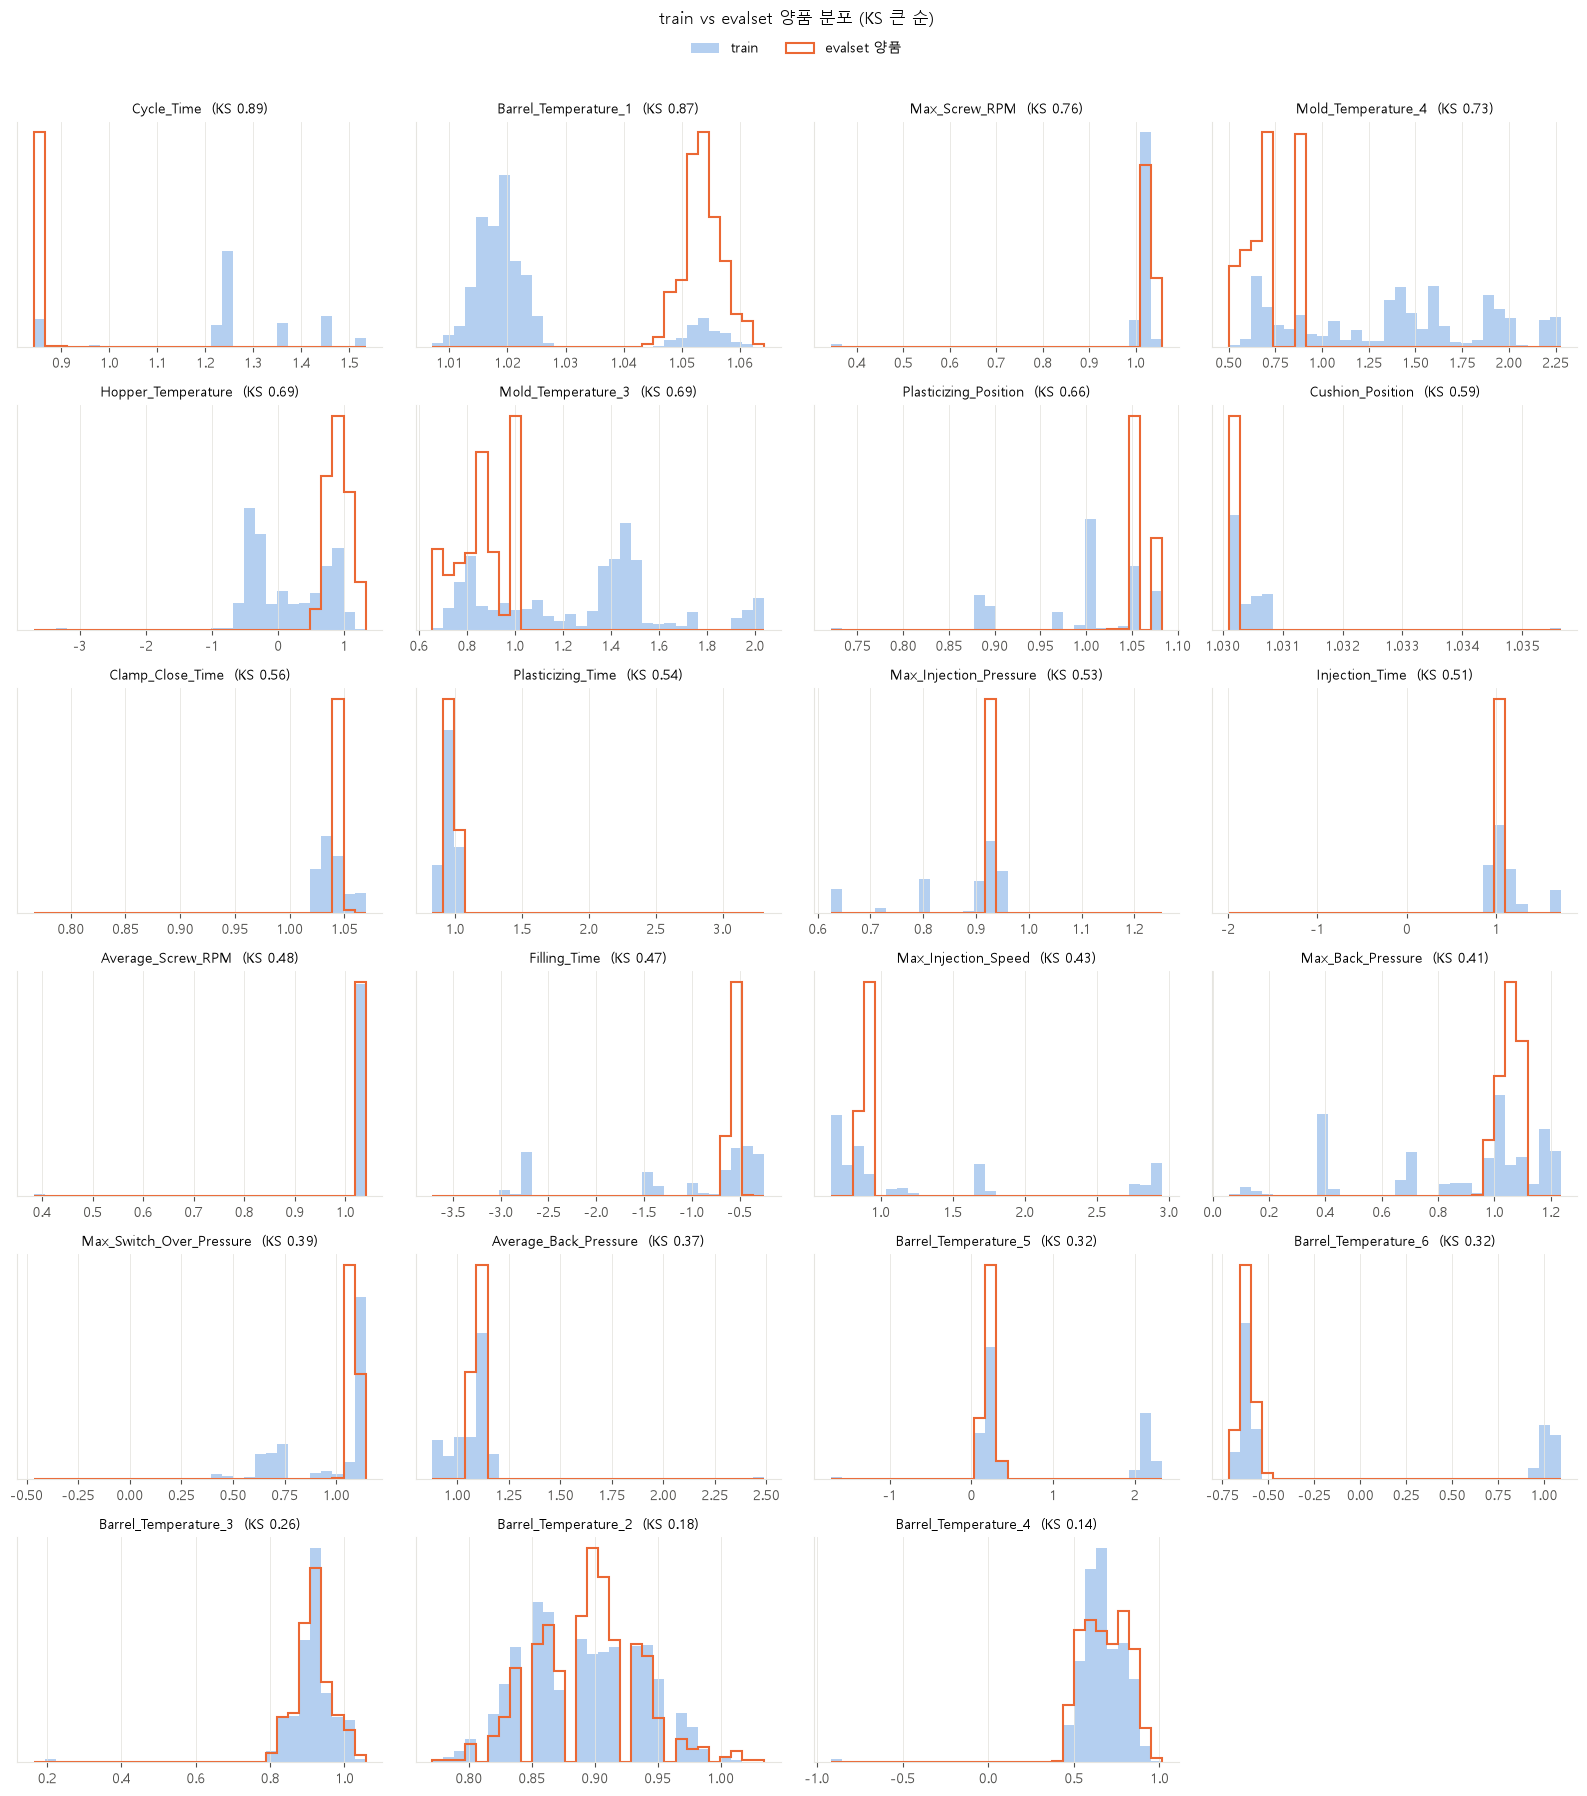

In [32]:
fig, axes = plt.subplots(6, 4, figsize=(16, 18))
for ax, c in zip(axes.flat, shift.index):
    # train 극단값 때문에 축이 넓어지지 않도록 train 상하위 0.5%는 범위에서 제외
    lo = min(train[c].quantile(0.005), ok[c].min())
    hi = max(train[c].quantile(0.995), ok[c].max())
    bins = np.linspace(lo, hi, 31)
    ax.hist(train[c], bins=bins, density=True, color=C_MAIN, alpha=0.35, label='train')
    ax.hist(ok[c], bins=bins, density=True, histtype='step', linewidth=1.5, color=C_SUB, label='evalset 양품')
    ax.set_title(f'{c}  (KS {shift.loc[c, "KS"]:.2f})')
    ax.set_yticks([])
for ax in axes.flat[len(shift):]:
    ax.axis('off')
fig.legend(*axes.flat[0].get_legend_handles_labels(), loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.985))
fig.suptitle('train vs evalset 양품 분포 (KS 큰 순)', y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

### 4-2. 불량 vs 양품 비교 (evalset)

피처별로 불량과 양품의 공정 값 차이가 있는지 본다.
- **샷 단위로 비교**한다: 한 샷의 두 부품은 공정 값이 같아서, 부품 단위로 세면 같은 값이 두 번 들어가 p값이 실제보다 작아진다. 샷 라벨 = 두 부품 중 하나라도 불량이면 1.
- 23개를 동시에 검정하므로 우연히 작은 p가 나올 수 있어 **q(다중검정 보정, BH)** 도 같이 본다 (q < 0.05면 의미 있는 차이).

In [33]:
ok_s = shots[shots[TARGET] == 0]   # 양품 샷
ng_s = shots[shots[TARGET] == 1]   # 불량 샷

p = [mannwhitneyu(ng_s[c], ok_s[c]).pvalue for c in FEATS]
diff = pd.DataFrame({
    '불량-양품 평균차(σ)': ((ng_s[FEATS].mean() - ok_s[FEATS].mean()) / sd).values,
    'p': p,
    'q': false_discovery_control(p),
}, index=FEATS)
diff = diff.loc[diff['불량-양품 평균차(σ)'].abs().sort_values(ascending=False).index].round(3)
diff

,불량-양품 평균차(σ),p,q
Mold_Temperature_3,0.378,0.000,0.000
Mold_Temperature_4,0.369,0.000,0.000
Barrel_Temperature_2,-0.205,0.186,0.268
Hopper_Temperature,-0.155,0.009,0.021
Plasticizing_Position,0.147,0.000,0.000
Max_Back_Pressure,-0.136,0.000,0.000
Clamp_Close_Time,0.112,0.000,0.000
Barrel_Temperature_4,0.078,0.610,0.651
Max_Injection_Speed,0.071,0.026,0.047
Average_Back_Pressure,-0.060,0.000,0.000


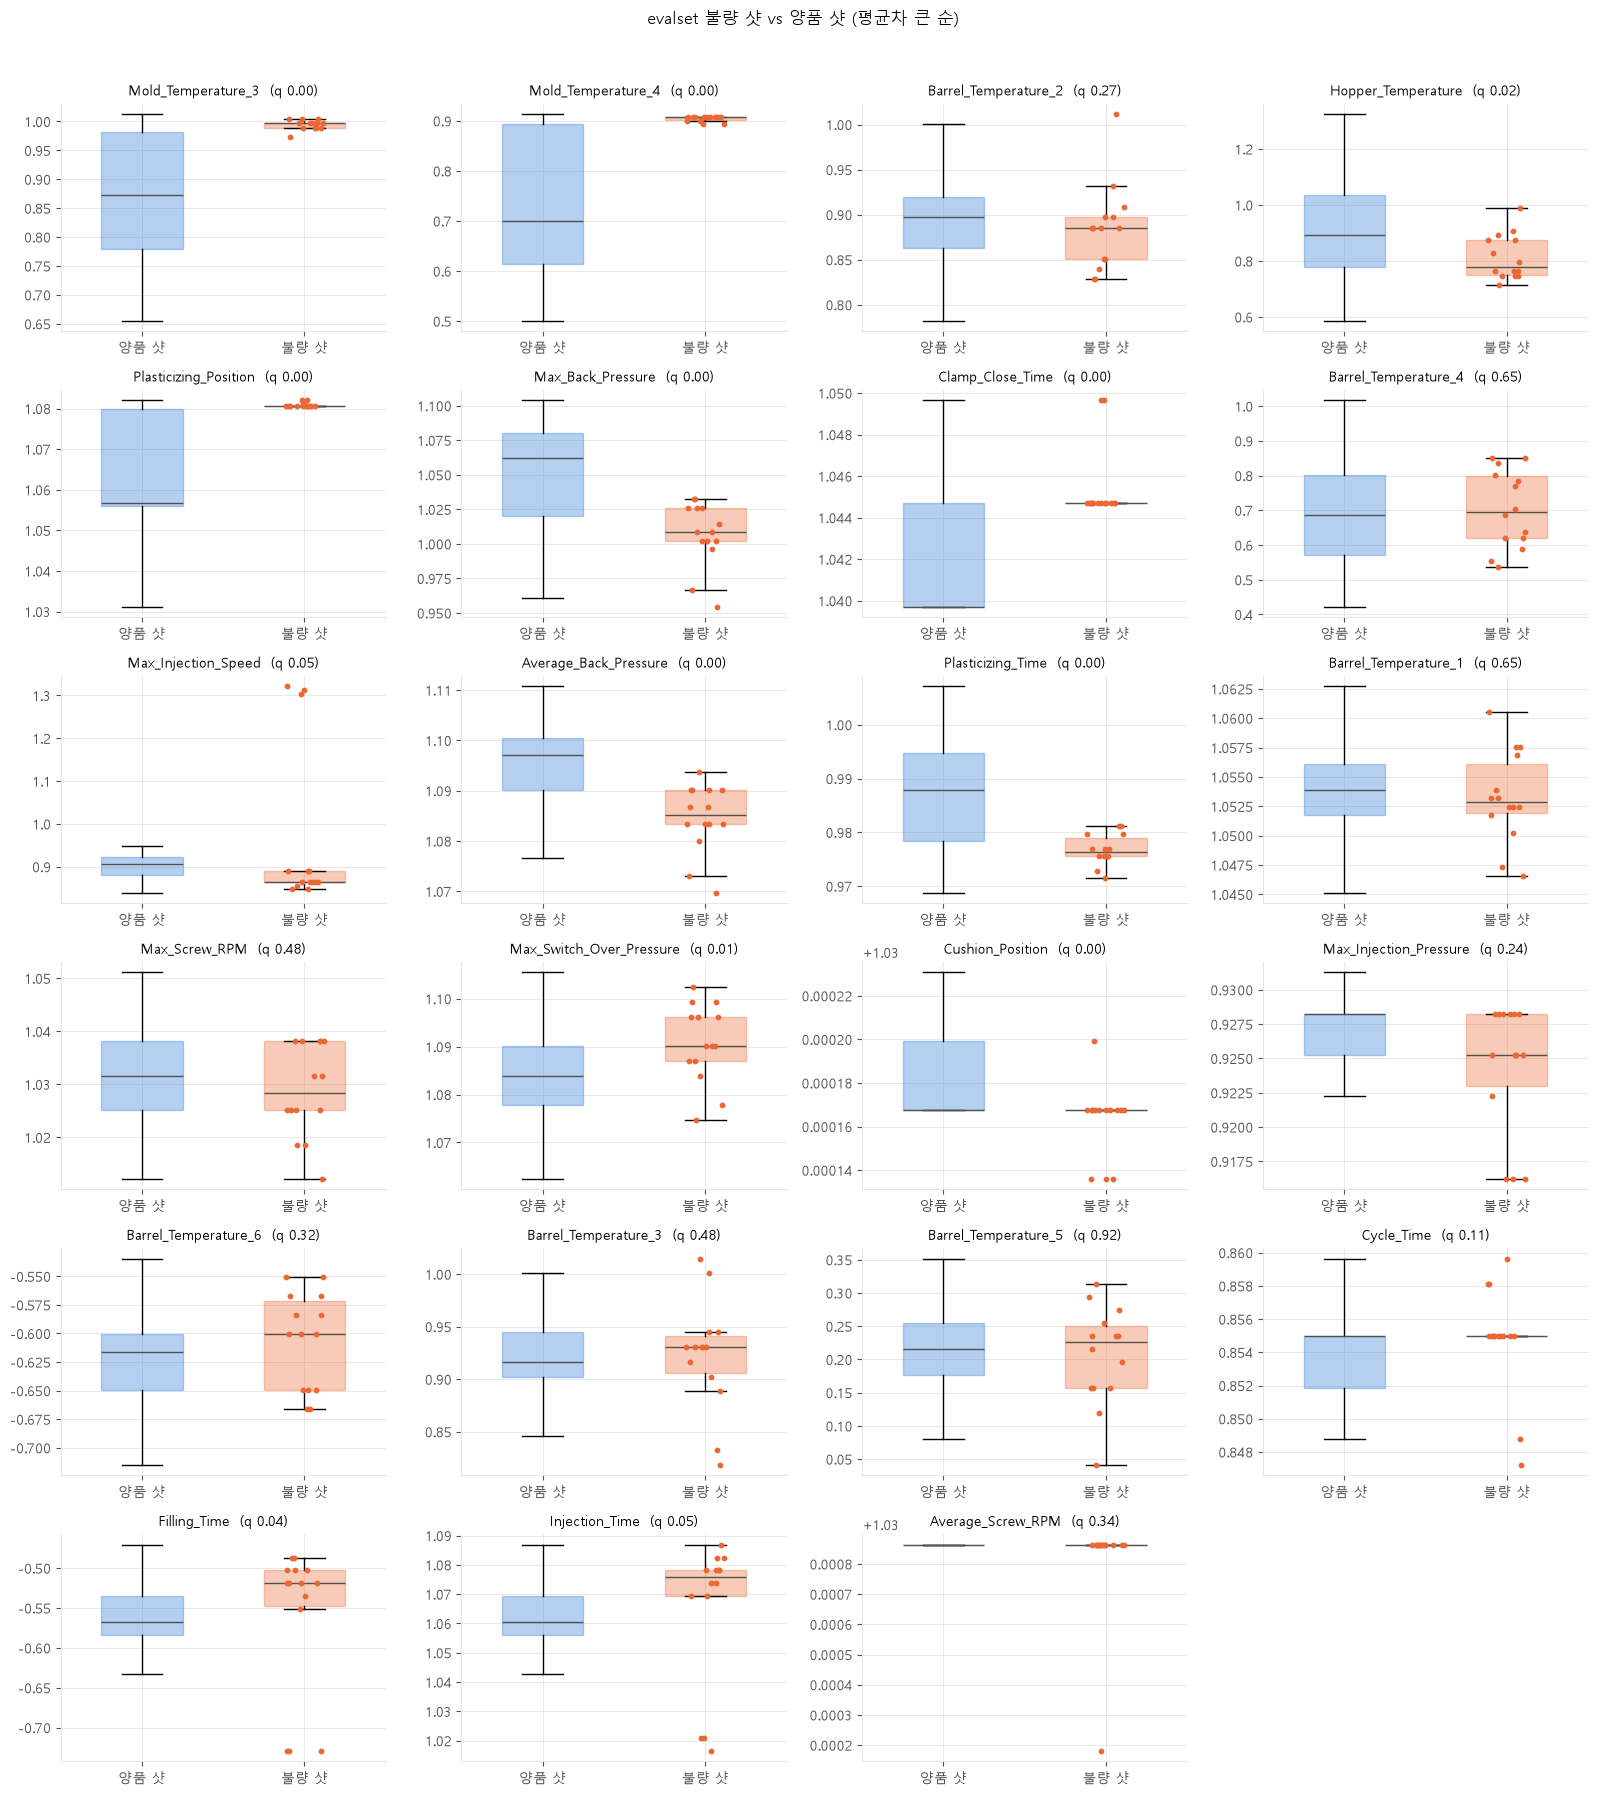

In [34]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(6, 4, figsize=(16, 18))
for ax, c in zip(axes.flat, diff.index):
    bp = ax.boxplot([ok_s[c], ng_s[c]], tick_labels=['양품 샷', '불량 샷'], widths=0.5, patch_artist=True,
                    showfliers=False, medianprops={'color': C_INK})
    for box, col in zip(bp['boxes'], [C_MAIN, C_SUB]):
        box.set(facecolor=col, alpha=0.35, edgecolor=col)
    # 불량 샷은 수가 적어 점으로도 표시
    ax.scatter(2 + rng.uniform(-0.12, 0.12, len(ng_s)), ng_s[c], s=10, color=C_SUB, zorder=3)
    ax.set_title(f'{c}  (q {diff.loc[c, "q"]:.2f})')
for ax in axes.flat[len(diff):]:
    ax.axis('off')
fig.suptitle('evalset 불량 샷 vs 양품 샷 (평균차 큰 순)', y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

#### 쌍 순서(`pair_pos`)와 불량

공정 값 23개와 달리, 쌍 안의 순서는 불량과 강하게 연결되어 있는지 확인한다. 순서가 무작위라면 불량은 앞/뒤에 반씩 나뉘어야 한다.

In [35]:
ng_front = (ng['pair_pos'] == 0).sum()
print(f'불량 {len(ng)}개 중 쌍의 앞(0): {ng_front}개 → 이항검정 p = {binomtest(ng_front, len(ng), 0.5).pvalue:.1e}')
print(f'앞(0) 부품만 검사하면: 검사 비율 {(evalset["pair_pos"] == 0).mean():.0%}, 불량 포착 {ng_front / len(ng):.0%}')

pd.crosstab(evalset['pair_pos'].map({0: '0 (앞)', 1: '1 (뒤)'}),
            evalset[TARGET].map({0: '양품', 1: '불량'}),
            margins=True, margins_name='합계')

불량 17개 중 쌍의 앞(0): 13개 → 이항검정 p = 4.9e-02
앞(0) 부품만 검사하면: 검사 비율 50%, 불량 포착 76%


PassOrFail,불량,양품,합계
pair_pos,,,
0 (앞),13,593,606
1 (뒤),4,601,605
합계,17,1194,1211


### 4-3. 라벨 시차 확인

불량 판정이 실제로는 앞/뒤 샷의 결과일 가능성을 확인한다. 라벨을 ±3샷 옮겨 4-2를 반복한다.
- lag = +1 : 불량 **다음** 샷의 피처와 비교 / lag = −1 : 불량 **이전** 샷의 피처와 비교

> 부품 단위로 옮기면 같은 샷의 짝(공정 값 동일)과 비교하게 되므로, **샷 단위(`shots`)** 로 본다. 샷 라벨 = 두 부품 중 하나라도 불량이면 1.

In [36]:
rows = []
for lag in range(-3, 4):
    y = shots[TARGET].shift(lag)
    m = y.notna()
    X, yy = shots.loc[m, FEATS], y[m]
    eff = ((X[yy == 1].mean() - X[yy == 0].mean()) / sd).abs()
    p_lag = np.array([mannwhitneyu(X.loc[yy == 1, c], X.loc[yy == 0, c]).pvalue for c in FEATS])
    rows.append({'lag': lag, '최대 평균차(σ)': eff.max(), '해당 피처': eff.idxmax(),
                 '최소 p': p_lag.min(), '최소 q': false_discovery_control(p_lag).min()})
lag_tbl = pd.DataFrame(rows).set_index('lag').round(3)
lag_tbl

,최대 평균차(σ),해당 피처,최소 p,최소 q
lag,,,,
-3,0.506,Barrel_Temperature_2,0.0,0.0
-2,0.381,Mold_Temperature_3,0.0,0.0
-1,0.508,Barrel_Temperature_2,0.0,0.0
0,0.378,Mold_Temperature_3,0.0,0.0
1,0.438,Barrel_Temperature_2,0.0,0.0
2,0.369,Mold_Temperature_3,0.0,0.0
3,0.385,Barrel_Temperature_2,0.0,0.0


### 4-4. 시간 흐름 (샷 순서)

평가 구간 안에서 값이 흘러가는지(drift), 불량이 특정 시점에 몰리는지 본다. 4-2에서 평균차가 큰 피처 3개와, 4-3에서 신호가 가장 강했던 피처를 그린다.

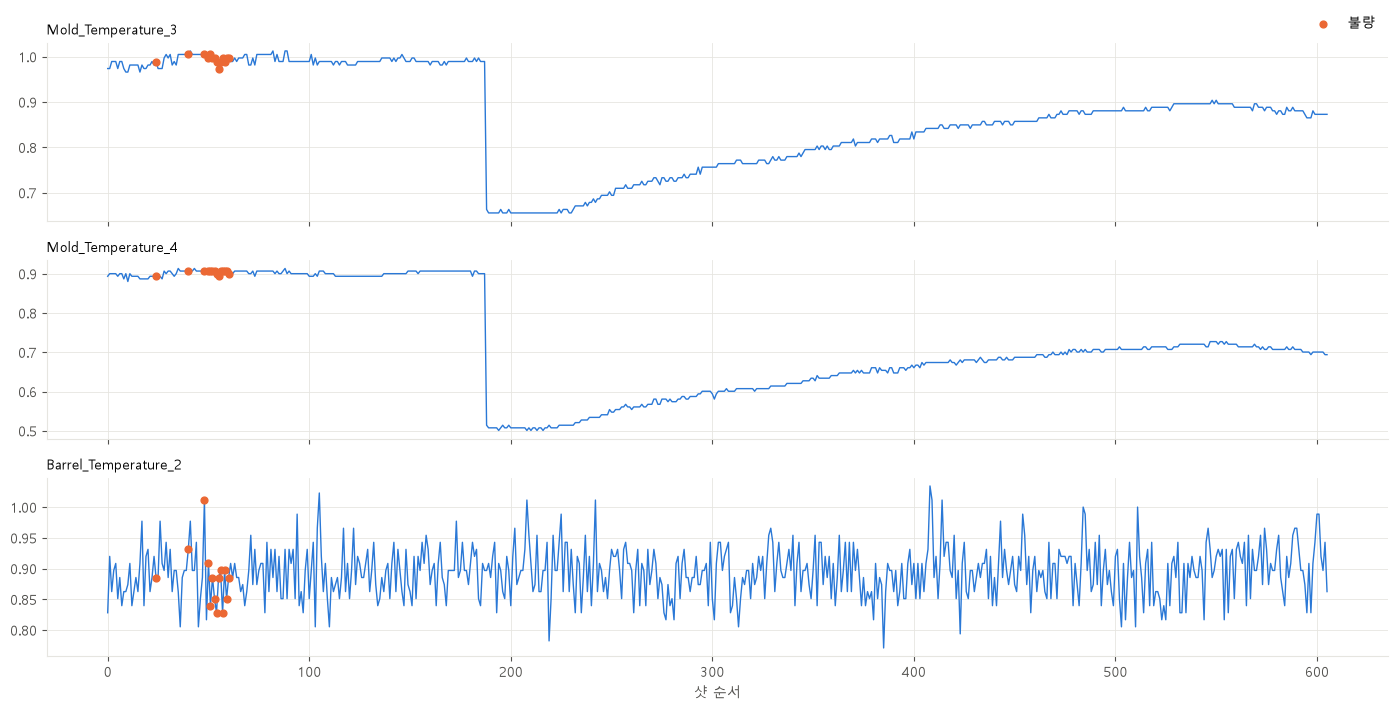

In [37]:
lag_feat = lag_tbl.loc[lag_tbl['최소 q'].idxmin(), '해당 피처']      # 4-3에서 신호가 가장 강한 피처
top4 = list(dict.fromkeys(list(diff.index[:3]) + [lag_feat]))
pos = np.arange(len(shots))
is_ng = shots[TARGET].values == 1

fig, axes = plt.subplots(len(top4), 1, figsize=(14, 2.4 * len(top4)), sharex=True)
for ax, c in zip(axes, top4):
    ax.plot(pos, shots[c].values, color=C_MAIN, linewidth=1)
    ax.scatter(pos[is_ng], shots[c].values[is_ng], s=24, color=C_SUB, zorder=3, label='불량')
    ax.set_title(c, loc='left')
axes[0].legend(loc='lower right', bbox_to_anchor=(1, 1), frameon=False)
axes[-1].set_xlabel('샷 순서')
plt.tight_layout()
plt.show()

In [38]:
# 불량 간 간격: 몰려 있으면 짧은 간격이 많다
ng_pos = pos[is_ng]
print('불량 위치(순서):', ng_pos.tolist())
print('불량 간 간격:', np.diff(ng_pos).tolist())
print(f'평균 간격 {np.diff(ng_pos).mean():.1f}샷 (고르게 퍼져 있다면 약 {len(shots) / len(ng_pos):.1f}샷)')

불량 위치(순서): [24, 40, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
불량 간 간격: [16, 8, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
평균 간격 2.8샷 (고르게 퍼져 있다면 약 43.3샷)


### 4-5. 상관관계 (train)

상관이 매우 높은 피처 쌍은 같은 정보를 중복으로 담고 있다 → 피처 선택 / PCA 여부 판단 근거.

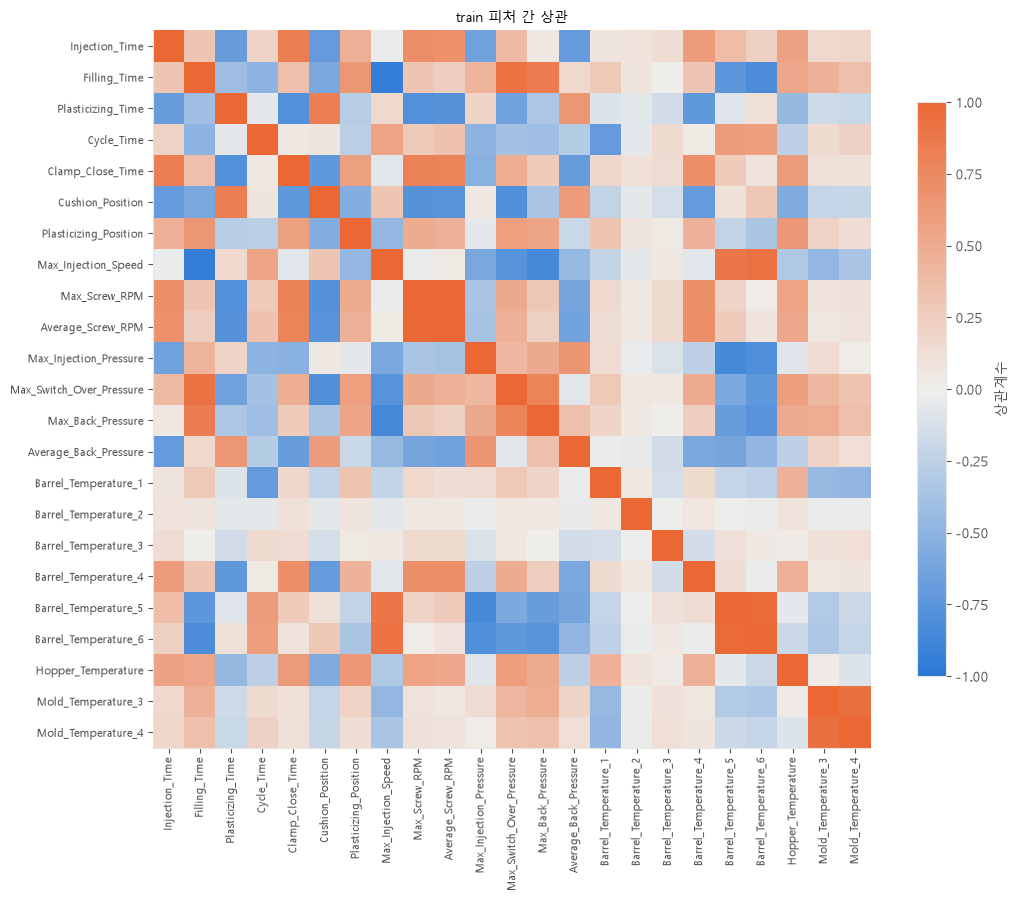

In [39]:
corr = train[FEATS].corr()
cmap = LinearSegmentedColormap.from_list('diverging', [C_MAIN, C_MID, C_SUB])

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATS)), FEATS, rotation=90, fontsize=8)
ax.set_yticks(range(len(FEATS)), FEATS, fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label='상관계수')
ax.set_title('train 피처 간 상관')
plt.tight_layout()
plt.show()

In [40]:
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
high_corr = upper[upper.abs() > 0.9].sort_values(key=abs, ascending=False).round(3)
high_corr.rename('상관계수').to_frame()

,,상관계수
Max_Screw_RPM,Average_Screw_RPM,0.993
Barrel_Temperature_5,Barrel_Temperature_6,0.975
Filling_Time,Max_Injection_Speed,-0.939
Mold_Temperature_3,Mold_Temperature_4,0.934
Filling_Time,Max_Switch_Over_Pressure,0.911
Max_Injection_Speed,Barrel_Temperature_6,0.909


### 4-6. 거의 상수인 피처

evalset에서 고유값이 몇 개 안 되는 피처는 평가 구간에서 정보가 거의 없다.

In [41]:
nuniq = pd.DataFrame({
    'train': train[FEATS].nunique(),
    'evalset': evalset[FEATS].nunique(),
}).sort_values('evalset')
nuniq.head(8)

,train,evalset
Clamp_Close_Time,35,3
Cushion_Position,37,5
Average_Screw_RPM,31,7
Max_Screw_RPM,16,8
Max_Injection_Pressure,81,8
Cycle_Time,139,13
Plasticizing_Position,108,13
Barrel_Temperature_6,35,13


### 4-7. train 극단값 (|z| > 6)

섹션 3에서 보류한 극단값 행이 어느 피처에서 나오고, 시간상 몰려 있는지 본다.
몰려 있으면 특정 시점의 이상 상황(가동 초기 등), 흩어져 있으면 개별 이상 샷일 가능성이 크다.

In [42]:
z = (train[FEATS] - train[FEATS].mean()) / sd
extreme = z.abs() > 6
ext_rows = extreme.any(axis=1)

print('극단값 행:', ext_rows.sum(), '/', len(train))
extreme.sum()[lambda s: s > 0].sort_values(ascending=False).rename('극단값 수').to_frame()

극단값 행: 58 / 3541


,극단값 수
Injection_Time,39
Cushion_Position,39
Barrel_Temperature_4,39
Average_Back_Pressure,37
Average_Screw_RPM,36
Max_Screw_RPM,36
Clamp_Close_Time,35
Plasticizing_Time,29
Barrel_Temperature_3,17
Hopper_Temperature,11


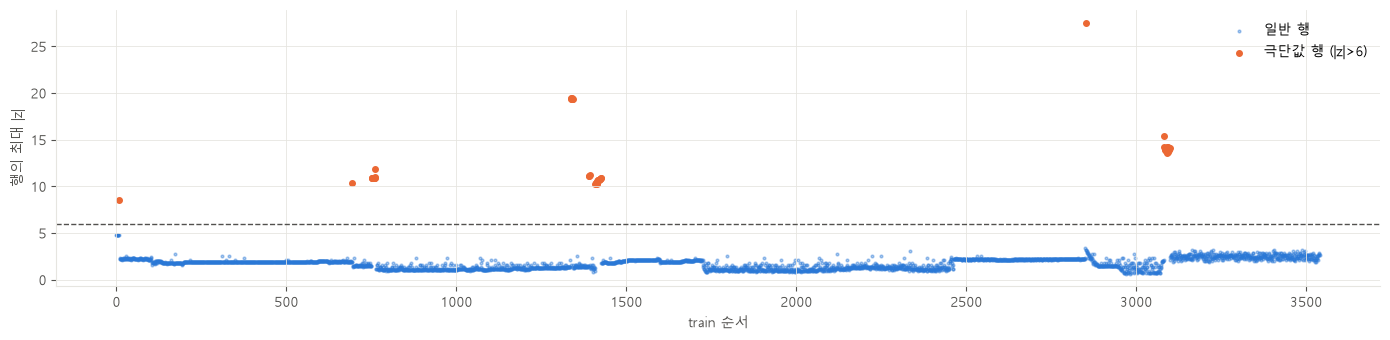

극단값 행 58개 → 5행 이내로 붙어 있는 묶음 8개


In [43]:
order = np.arange(len(train))
max_z = z.abs().max(axis=1).values

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.scatter(order[~ext_rows.values], max_z[~ext_rows.values], s=4, color=C_MAIN, alpha=0.4, label='일반 행')
ax.scatter(order[ext_rows.values], max_z[ext_rows.values], s=16, color=C_SUB, label='극단값 행 (|z|>6)')
ax.axhline(6, color=C_INK, linewidth=1, linestyle='--')
ax.set_xlabel('train 순서')
ax.set_ylabel('행의 최대 |z|')
ax.legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

ext_pos = order[ext_rows.values]
runs = (np.diff(ext_pos) > 5).sum() + 1
print(f'극단값 행 {len(ext_pos)}개 → 5행 이내로 붙어 있는 묶음 {runs}개')

In [44]:
# |z|가 가장 큰 행들: 어떤 피처가 튀었는지
top_ext = z.abs().max(axis=1).nlargest(8)
pd.DataFrame({
    '최대 |z|': top_ext.round(1),
    '|z|>6 피처': [', '.join(z.columns[z.loc[i].abs() > 6]) for i in top_ext.index],
})

,최대 |z|,|z|>6 피처
662748,27.5,"Cycle_Time, Max_Screw_RPM, Average_Screw_RPM, ..."
509786,19.4,"Injection_Time, Clamp_Close_Time, Cushion_Posi..."
510074,19.4,"Injection_Time, Clamp_Close_Time, Cushion_Posi..."
512385,19.4,"Injection_Time, Clamp_Close_Time, Cushion_Posi..."
512624,19.4,"Injection_Time, Clamp_Close_Time, Cushion_Posi..."
507782,19.4,"Injection_Time, Clamp_Close_Time, Cushion_Posi..."
511917,19.4,"Injection_Time, Clamp_Close_Time, Cushion_Posi..."
735217,15.4,Barrel_Temperature_3


### 4-8. 정리

| 항목 | 결과 | 모델링에 주는 의미 |
|---|---|---|
| 4-1 학습/평가 분포 | KS ≥ 0.8인 피처 2개 (Cycle_Time 0.89, Barrel_Temperature_1 0.87; 평균 이동 −1.96σ / +2.47σ). Max_Screw_RPM·Mold_Temperature_3·4·Hopper_Temperature도 KS 0.69~0.76. Barrel_Temperature_2~4는 차이 작음 (KS ≤ 0.26) | 그대로 학습하면 평가 양품도 이상으로 잡힐 위험 → 섹션 6 설정 B와 6-5(분포 차이 큰 피처 제외)에서 확인 |
| 4-2 불량 vs 양품 (공정 값, 샷 단위) | q < 0.05인 피처 **13개**. 가장 큰 차이는 Mold_Temperature_3·4 (0.38σ·0.37σ, q < 0.001) | RG3(0개)와 달리 공정 값에 차이가 있다. 단 4-4의 시간 몰림 때문에 **불량 차이인지 시기 차이인지** 가려야 함 → 8-2 (b) |
| 4-2 불량 vs 양품 (쌍 순서) | 불량 17개 중 13개가 쌍의 앞(0) (이항검정 p = 0.049). 앞 부품만 검사하면 검사 50%로 불량 76% 포착. 두 부품 모두 불량인 샷 3개 | RG3(23/25, p = 1.9e-05)보다 약한 신호. `pair_pos`는 RG3와 같이 섹션 7에서 사용 (해석 A 가정) |
| 4-3 라벨 시차 (샷 단위) | lag −3 ~ +3 **모두** 최소 q ≈ 0 (Barrel_Temperature_2 / Mold_Temperature_3, 0.37~0.51σ) | 라벨을 몇 샷 옮겨도 신호가 그대로 → 개별 불량 샷이 아니라 **불량이 몰린 시기 전체**가 다르다는 신호 |
| 4-4 시간 흐름 | 불량 샷 14개가 모두 샷 24~60 (606샷 중 앞 10%), 50~60은 연속. 평균 간격 2.8샷 (고르게 퍼져 있다면 43.3샷). 샷 61 이후 1,090부품은 불량 0 | **불량이 한 시기에 몰려 있다** → 시간 순 검증(7-3) 불가, 공정 값 신호 해석에 주의 |
| 4-5 상관관계 | 0.9 이상 6쌍 (Max·Average_Screw_RPM 0.99, Barrel_Temperature_5–6 0.98, Filling_Time–Max_Injection_Speed −0.94, Mold_Temperature_3–4 0.93, Filling_Time–Max_Switch_Over_Pressure 0.91, Max_Injection_Speed–Barrel_Temperature_6 0.91) | 6-5에서 한쪽씩 빼 봄 |
| 4-6 거의 상수 | evalset에서 Clamp_Close_Time 3개, Cushion_Position 5개 값 | 6-5에서 빼 봄 (3개 이하: 1개) |
| 4-7 train 극단값 | 58행 / 8묶음. idx 507782~512624에 Injection_Time·Clamp_Close_Time·Cushion_Position 등이 동시에 \|z\| 19.4인 행이 반복, 662748은 최대 27.5σ, 735217은 Barrel_Temperature_3만 15.4σ | 6-5에서 빼 봄 |

# 5. 평가 설계

모델을 만들기 전에 **무엇을, 어떻게 채점하고, 무엇과 비교할지** 정한다.

- **정답을 쓰지 않는 곳**: 이상 점수는 `train`(unlabeled)으로만 학습한 모델이 매긴다 → 순위 지표는 `evalset` 전체로 잰다.
- **정답을 쓰는 곳**: 임계값·점수 결합 방식 선택은 교차검증 안에서만 한다 (같은 데이터로 맞추고 채점하면 성능이 부풀려진다).
- **평가 단위**: 부품(1,211개). 실제 검사가 부품 단위이기 때문.

### 5-1. 교차검증 분할: StratifiedGroupKFold 5-fold × 10회

| 구성 | 뜻 | 이유 |
|---|---|---|
| Group (`shot_id`) | 같은 샷의 두 부품은 같은 fold | 두 부품은 공정 값이 같아서, 갈라지면 누수 |
| Stratified | fold마다 불량 비율 유지 | 불량 17개 → 불량 0개인 fold 방지 |
| 5-fold | 4/5로 임계값 결정, 1/5로 채점 | fold당 불량 3~4개 확보 |
| 10회 반복 | 분할을 바꿔 평균 ± 표준편차 | 불량 1개 = 재현율 약 6%p라 한 번의 분할은 운에 좌우 |

주 평가에는 시간 분할을 쓰지 않고(RG3와 동일), **7-3에서 시간 순 검증을 보조로** 한다 (앞 구간으로 정하고 뒤 구간에 적용). 4-4에서 불량이 시간상 몰려 있다면 이 선택을 다시 검토한다.
> 이 분할은 섹션 7(임계값)에서 사용한다.

In [45]:
N_SPLITS, N_REPEATS = 5, 10
y_eval = evalset[TARGET].values
groups = evalset['shot_id'].values

cv_splits = [
    (tr, te)
    for r in range(N_REPEATS)
    for tr, te in StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + r).split(evalset, y_eval, groups)
]

fold_ng = pd.Series([y_eval[te].sum() for _, te in cv_splits])
shared = sum(len(set(groups[tr]) & set(groups[te])) for tr, te in cv_splits)
print('fold 수:', len(cv_splits))
print('fold당 불량 수:', fold_ng.value_counts().to_dict())
print('train·test에 같이 들어간 샷:', shared)

fold 수: 50
fold당 불량 수: {3: 30, 4: 20}
train·test에 같이 들어간 샷: 0


### 5-2. 지표

| 지표 | 뜻 | 이유 |
|---|---|---|
| **검사율@재현율1** (주 지표) | 위험 점수 순으로 검사할 때, 불량을 **전부** 잡으려면 몇 %를 검사해야 하나 | 팀 목표(재현율 1.0)를 검사량(비용)으로 바꾼 값. ROI 계산의 입력 |
| 검사율@재현율0.92 (보조) | 불량 17개 중 16개를 잡는 데 필요한 검사 비율 (⌈0.92 × 17⌉ = 16) | 재현율 1.0은 가장 잡기 어려운 불량 1개로 결정되어 흔들림이 큼 |
| 재현율@k% (10/20/30/50) | 상위 k%만 검사했을 때 잡은 불량 비율 | 검사 가능량이 정해진 현장 상황 |
| PR-AUC | 전체 순위에서 불량을 얼마나 위에 모았나 | 불량이 드물 때의 대표 순위 지표 (무작위 ≈ 불량률 0.014) |
| ROC-AUC (참고) | 불량·양품 한 쌍에서 불량 점수가 더 높을 확률 | 익숙해서 참고용. 불량이 드물면 낙관적 |

정확도(전부 양품이라 해도 98.6%)는 쓰지 않는다. F1·Recall·PR-AUC는 **팀 공통 지표**라 8-1에 별도 표로 보고하되, 불량률이 1.4%라 F1은 정밀도 상한 때문에 낮게 나오므로 판단은 검사율·재현율 중심으로 한다.

**불확실성**: 불량이 17개뿐이므로 **샷 단위 부트스트랩 95% 구간**을 같이 적는다 (샷을 복원추출로 다시 뽑아 1,000번 재계산).
**동점 처리**: 점수가 같은 부품은 무작위 순서로 검사한다고 보고, 200번 무작위로 줄 세운 평균을 값으로 쓴다.

In [46]:
RECALL_TARGETS = [1.0, 0.92]
TOP_K = [10, 20, 30, 50]


def ranking_metrics(y, score, rng):
    """위험 점수가 높은 순으로 검사할 때의 지표 (동점은 rng로 무작위 순서)"""
    n, p = len(y), y.sum()
    order = np.lexsort((rng.random(n), -score))  # 1순위: 점수 내림차순, 2순위: 무작위
    caught = np.cumsum(y[order])                 # 상위 i개 검사 시 잡은 불량 수
    out = {}
    for r in RECALL_TARGETS:
        need = np.ceil(r * p - 1e-9)             # 잡아야 할 불량 수 (부동소수 오차 방지)
        out[f'검사율@재현율{r:g}'] = (np.argmax(caught >= need) + 1) / n
    for k in TOP_K:
        out[f'재현율@{k}%'] = caught[int(np.ceil(n * k / 100)) - 1] / p
    # PR-AUC / ROC-AUC도 같은 줄세우기(동점 무작위) 순위로 계산
    rank_score = np.empty(n)
    rank_score[order] = np.arange(n, 0, -1)
    out['PR-AUC'] = average_precision_score(y, rank_score)
    out['ROC-AUC'] = roc_auc_score(y, rank_score)
    return out


shot_rows = pd.Series(evalset.groupby('shot_id').indices).sort_index().values  # 샷별 부품 위치
n_shots = len(shot_rows)


def evaluate(score_fn, n_rank=200, n_boot=1000, seed=SEED):
    """score_fn(rng) → 부품별 위험 점수. 값 = 무작위 줄세우기 평균, 구간 = 샷 단위 부트스트랩 95%"""
    rng = np.random.default_rng(seed)
    point = pd.DataFrame([ranking_metrics(y_eval, score_fn(rng), rng) for _ in range(n_rank)]).mean()
    boot = []
    for _ in range(n_boot):
        idx = np.concatenate(shot_rows[rng.choice(n_shots, n_shots, replace=True)])
        boot.append(ranking_metrics(y_eval[idx], score_fn(rng)[idx], rng))
    boot = pd.DataFrame(boot)
    return pd.DataFrame({'값': point, '95% 하한': boot.quantile(0.025), '95% 상한': boot.quantile(0.975)})


def fmt(res):
    """'값 (하한~상한)' 형식의 한 열"""
    return res.apply(lambda s: f"{s['값']:.3f} ({s['95% 하한']:.2f}~{s['95% 상한']:.2f})", axis=1)

### 5-3. 기준선

모델이 넘어야 할 두 기준.
- **무작위**: 모델이 아무것도 모를 때의 바닥선.
- **쌍 순서 규칙**: 앞쪽 부품(`pair_pos` = 0)을 먼저 검사, 같은 그룹 안에서는 무작위. 모델 없이 얻을 수 있는 성능.

> 주의: "앞쪽이 위험하다"는 **방향은 이 evalset에서 찾은 것**이라, 같은 데이터로 잰 이 기준선은 원칙적으로 낙관적이다. 방향까지 학습 fold에서 정하는 공정한 추정은 7-1(교차검증 50개 fold 모두 같은 방향)과 7-2, 시간 순 검증은 7-3에서 본다. 또한 해석 A(3-7)를 가정한다.

In [47]:
%%time
baselines = {
    '무작위': lambda rng: rng.random(len(evalset)),
    '쌍 순서 규칙': lambda rng: (evalset['pair_pos'].values == 0).astype(float),
}
base_res = {name: evaluate(fn) for name, fn in baselines.items()}
pd.DataFrame({name: fmt(res) for name, res in base_res.items()})

CPU times: total: 3.8 s
Wall time: 3.84 s


,무작위,쌍 순서 규칙
검사율@재현율1,0.946 (0.69~1.00),0.893 (0.56~1.00)
검사율@재현율0.92,0.898 (0.62~1.00),0.790 (0.46~0.98)
재현율@10%,0.103 (0.00~0.35),0.159 (0.00~0.33)
재현율@20%,0.208 (0.00~0.50),0.314 (0.09~0.54)
재현율@30%,0.305 (0.00~0.62),0.463 (0.24~0.71)
재현율@50%,0.498 (0.18~0.83),0.765 (0.60~0.94)
PR-AUC,0.019 (0.01~0.06),0.029 (0.01~0.08)
ROC-AUC,0.498 (0.31~0.71),0.637 (0.53~0.75)


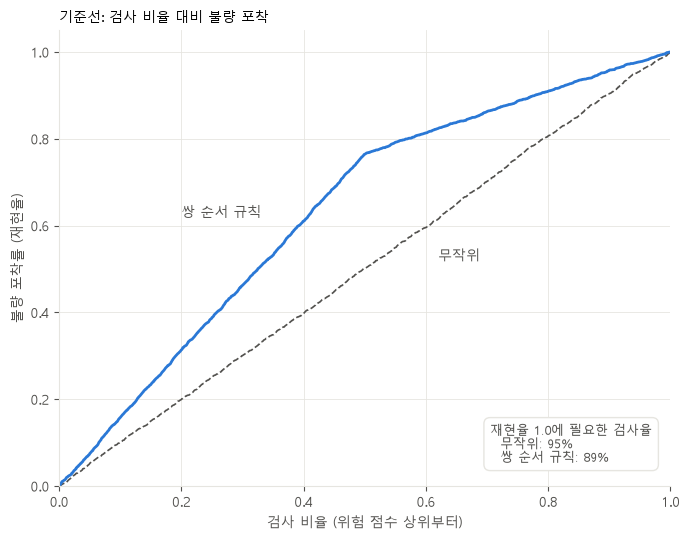

In [48]:
def capture_curve(score_fn, n_rank=200, seed=SEED):
    """검사 비율(0~1)별 평균 재현율"""
    rng = np.random.default_rng(seed)
    n, p = len(y_eval), y_eval.sum()
    curves = []
    for _ in range(n_rank):
        order = np.lexsort((rng.random(n), -score_fn(rng)))
        curves.append(np.concatenate([[0], np.cumsum(y_eval[order]) / p]))
    return np.linspace(0, 1, n + 1), np.mean(curves, axis=0)


fig, ax = plt.subplots(figsize=(7, 5.5))
x, y_rand = capture_curve(baselines['무작위'])
_, y_pair = capture_curve(baselines['쌍 순서 규칙'])
ax.plot(x, y_rand, color=C_INK, linewidth=1.2, linestyle='--')
ax.plot(x, y_pair, color=C_MAIN, linewidth=2)
ax.text(0.62, 0.52, '무작위', color=C_INK)
ax.text(0.2, 0.62, '쌍 순서 규칙', color=C_INK)

# 재현율 1.0에 필요한 검사율 (평균 곡선이 아니라 줄세우기마다 계산한 값의 평균)
r1 = {name: base_res[name].loc['검사율@재현율1', '값'] for name in base_res}
ax.text(0.97, 0.05, '\n'.join(['재현율 1.0에 필요한 검사율'] + [f'  {k}: {v:.0%}' for k, v in r1.items()]),
        ha='right', va='bottom', multialignment='left', color=C_INK, fontsize=9,
        bbox={'facecolor': 'white', 'edgecolor': C_GRID, 'boxstyle': 'round,pad=0.5'})

ax.set_xlabel('검사 비율 (위험 점수 상위부터)')
ax.set_ylabel('불량 포착률 (재현율)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_title('기준선: 검사 비율 대비 불량 포착', loc='left')
plt.tight_layout()
plt.show()

> **모델의 목표**: 쌍 순서 규칙은 50% 검사로 불량 76%를 잡지만(ROC-AUC 0.64), 재현율 1.0에는 약 89%를 검사해야 한다 (뒤쪽 불량 4개가 무작위 위치에 섞여 있기 때문).
> RG3(50% 검사로 92%)보다 기준선이 약하다. 섹션 6~7의 모델은 이보다 적은 검사로 불량을 모아야 의미가 있다.

# 6. 이상탐지 모델

공정 값 23개로 **"평소와 얼마나 다른 샷인가"** 를 점수로 매기고, 그 점수가 불량을 가리키는지 확인한다.

이 섹션의 역할은
1. 이상탐지가 CN7에서 작동하는지, 실패한다면 **원인을 분리**하고 (작동·실패 조건 분석의 근거),
2. 섹션 7에서 쌍 순서와 결합할 **이상 점수**를 만드는 것이다.

실패 원인 후보는 두 가지다.
- **분포 차이**: 평가 구간 전체가 train과 달라서(4-1), 점수가 "불량 여부"가 아니라 "train에서 얼마나 먼가"를 재게 된다.
- **신호 없음**: 평가 구간 안에서 불량과 양품의 공정 값이 같다(4-2).

| 설정 | 학습 데이터 | 확인하는 것 |
|---|---|---|
| **A** | `train` (unlabeled, 같은 운전 조건) | 계획한 방식의 실제 성능 (두 원인이 함께 작용) |
| **B** | 평가 구간의 공정 값만 (**라벨 미사용**, 샷 단위) | 분포 차이를 없애도 실패하면 → 근본 원인은 **신호 없음**. 현장에서 최근 생산분으로 모델을 다시 맞추는 방식과 같다 |

- 주 모델은 **Isolation Forest**, 가이드북의 **오토인코더**는 비교용으로 설정 A에서 한 번만 돌린다 (조정 없음).
- 6-5에서 전처리를 바꿔도 결론이 같은지, 6-6에서 **정답을 직접 준 모델**(지도학습)과 비교한다.
- 결과를 보고 설정을 고르지 않는다: 불량이 17개뿐이라 여러 설정 중 최고를 고르면 우연을 성능으로 보고하게 된다.

### 6-1. 표준화

- 설정 A: `train`에만 맞춘 기준으로 `train`·`evalset`을 표준화한다 (섹션 3 필터링으로 평균·표준편차가 바뀌었고, 평가 데이터 정보가 학습에 섞이면 안 됨).
- 설정 B: 평가 구간의 샷(606개, 라벨 미사용)에 맞춘 기준으로 표준화한다.
- 입력은 공정 값 23개. `pair_pos`는 unlabeled에 없고 공정 이상과 성격이 달라 섹션 7에서 따로 결합한다.

In [49]:
# 설정 A: train 기준
scaler_A = StandardScaler().fit(train[FEATS])
X_train = scaler_A.transform(train[FEATS])
X_eval_A = scaler_A.transform(evalset[FEATS])

# 설정 B: 평가 구간 샷 기준 (한 샷의 두 부품은 공정 값이 같으므로 샷당 한 번만)
eval_shots = evalset.drop_duplicates('shot_id')[FEATS]
scaler_B = StandardScaler().fit(eval_shots)
X_fit_B = scaler_B.transform(eval_shots)
X_eval_B = scaler_B.transform(evalset[FEATS])

print('설정 A 학습:', X_train.shape, '/ 설정 B 학습:', X_fit_B.shape, '/ 평가:', X_eval_A.shape)

설정 A 학습: (3541, 23) / 설정 B 학습: (606, 23) / 평가: (1211, 23)


### 6-2. Isolation Forest (주 모델)

무작위로 데이터를 계속 잘라 나갈 때, **적은 횟수로 혼자 떨어지는 점일수록 이상**하다고 본다.
- 학습 데이터에 불량이 섞여 있어도(unlabeled에 약 1.4% 추정) 강하다.
- 설정할 것이 거의 없어(트리 300개) 결과가 설정에 좌우되지 않는다.
- 이상 점수 = `-score_samples` (클수록 이상).

In [50]:
iso_A = IsolationForest(n_estimators=300, random_state=SEED).fit(X_train)
iso_B = IsolationForest(n_estimators=300, random_state=SEED).fit(X_fit_B)

scores = {
    'IF (A: train 학습)': -iso_A.score_samples(X_eval_A),
    'IF (B: 평가 구간 학습)': -iso_B.score_samples(X_eval_B),
}
fit_scores = {  # 학습 데이터 자신의 점수 (분포 비교용)
    'IF (A: train 학습)': -iso_A.score_samples(X_train),
    'IF (B: 평가 구간 학습)': -iso_B.score_samples(X_fit_B),
}

### 6-3. 오토인코더 (가이드북 방법, 비교용)

입력을 좁은 가운데 층으로 압축했다가 다시 복원하도록 학습한다. 흔한(정상) 패턴은 잘 복원하고, 낯선 패턴은 **복원 오차가 크다**.

| 구성 | 설정 | 이유 |
|---|---|---|
| 구조 | 23 → 16 → **6** → 16 → 23 | 가운데를 좁혀 압축을 강제 → 입력을 그대로 베끼지 못함. 상관이 높은 쌍이 많아(4-5) 실제 정보 차원은 23보다 작음 |
| 잡음 제거 | 입력에 노이즈(σ = 0.1)를 섞고 원래 값을 복원 | 베끼기 방지, 작은 흔들림에 둔감한 정상 패턴 학습 |
| 손실 / 옵티마이저 | 평균제곱오차 / Adam | 가이드북과 동일 |
| 학습 중단 | train의 10%를 검증용으로, 검증 성능이 멈추면 종료 | 과적합 방지. 라벨을 쓰지 않는 기준 |
| 이상 점수 | 부품별 복원 오차(MSE) | 평소 패턴에서 멀수록 큼 |

> scikit-learn `MLPRegressor`로 구현한다 (입력 → 입력 복원). 구조·손실·옵티마이저는 Keras 오토인코더와 같고, 데이터가 작아(train 수천 행 × 23) 충분하다.

In [51]:
rng = np.random.default_rng(SEED)
X_train_noisy = X_train + rng.normal(0, 0.1, X_train.shape)

ae = MLPRegressor(hidden_layer_sizes=(16, 6, 16), activation='relu', solver='adam', alpha=1e-4,
                  early_stopping=True, validation_fraction=0.1, max_iter=500, random_state=SEED)
ae.fit(X_train_noisy, X_train)


def recon_error(X):
    return ((ae.predict(X) - X) ** 2).mean(axis=1)


scores['AE (A: train 학습)'] = recon_error(X_eval_A)
fit_scores['AE (A: train 학습)'] = recon_error(X_train)
print('학습 반복 수:', ae.n_iter_)

학습 반복 수: 418


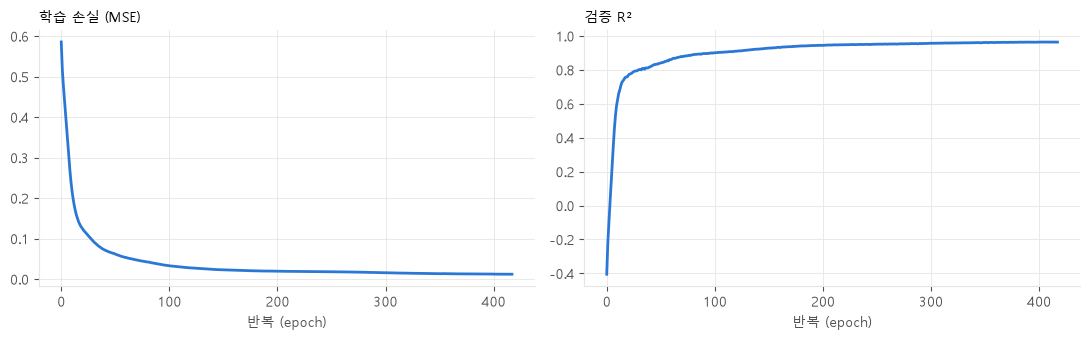

In [52]:
# 학습 곡선: 학습 손실이 줄고, 검증 성능(R², 1에 가까울수록 잘 복원)이 멈춘 지점에서 종료되었는지 확인
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(ae.loss_curve_, color=C_MAIN, linewidth=2)
axes[0].set_title('학습 손실 (MSE)', loc='left')
axes[0].set_xlabel('반복 (epoch)')
axes[1].plot(ae.validation_scores_, color=C_MAIN, linewidth=2)
axes[1].set_title('검증 R²', loc='left')
axes[1].set_xlabel('반복 (epoch)')
plt.tight_layout()
plt.show()

### 6-4. 비교

섹션 5의 기준선과 같은 표·같은 방식(샷 단위 부트스트랩 95% 구간)으로 비교한다.

In [53]:
%%time
model_res = {name: evaluate(lambda rng, s=s: s) for name, s in scores.items()}
all_res = {**base_res, **model_res}
pd.DataFrame({name: fmt(res) for name, res in all_res.items()})

CPU times: total: 5.62 s
Wall time: 5.69 s


,무작위,쌍 순서 규칙,IF (A: train 학습),IF (B: 평가 구간 학습),AE (A: train 학습)
검사율@재현율1,0.946 (0.69~1.00),0.893 (0.56~1.00),0.976 (0.85~0.99),0.301 (0.26~0.34),0.950 (0.62~0.97)
검사율@재현율0.92,0.898 (0.62~1.00),0.790 (0.46~0.98),0.968 (0.73~0.98),0.298 (0.16~0.33),0.734 (0.59~0.96)
재현율@10%,0.103 (0.00~0.35),0.159 (0.00~0.33),0.118 (0.00~0.38),0.529 (0.20~0.77),0.353 (0.08~0.63)
재현율@20%,0.208 (0.00~0.50),0.314 (0.09~0.54),0.235 (0.00~0.53),0.765 (0.50~0.94),0.353 (0.11~0.67)
재현율@30%,0.305 (0.00~0.62),0.463 (0.24~0.71),0.412 (0.10~0.65),0.970 (0.63~1.00),0.529 (0.23~0.79)
재현율@50%,0.498 (0.18~0.83),0.765 (0.60~0.94),0.588 (0.29~0.82),1.000 (1.00~1.00),0.647 (0.36~0.88)
PR-AUC,0.019 (0.01~0.06),0.029 (0.01~0.08),0.020 (0.01~0.06),0.218 (0.04~0.57),0.035 (0.01~0.09)
ROC-AUC,0.498 (0.31~0.71),0.637 (0.53~0.75),0.513 (0.32~0.69),0.889 (0.82~0.95),0.649 (0.47~0.80)


In [54]:
# 분포 차이 확인: 평가 구간 양품의 점수가 학습 데이터 점수보다 얼마나 높은가 (중앙값 비율)
pd.DataFrame({
    '평가 양품 / 학습 데이터 (중앙값 비율)': {n: np.median(scores[n][y_eval == 0]) / np.median(fit_scores[n]) for n in scores},
    '평가 불량 / 평가 양품 (중앙값 비율)': {n: np.median(scores[n][y_eval == 1]) / np.median(scores[n][y_eval == 0]) for n in scores},
}).round(2)

,평가 양품 / 학습 데이터 (중앙값 비율),평가 불량 / 평가 양품 (중앙값 비율)
IF (A: train 학습),1.05,1.00
IF (B: 평가 구간 학습),1.00,1.10
AE (A: train 학습),1.30,1.59


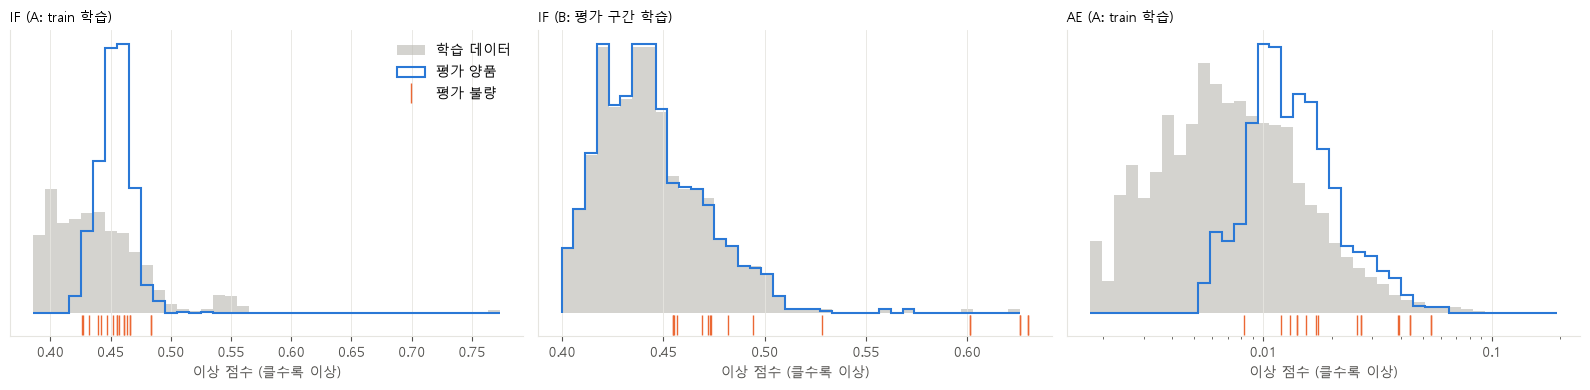

In [55]:
# 이상 점수 분포: 학습 데이터(회색) / 평가 양품(파랑) / 평가 불량(주황 눈금)
C_REF = '#b8b7b0'
fig, axes = plt.subplots(1, len(scores), figsize=(16, 4))
for ax, (name, s) in zip(axes, scores.items()):
    ref = fit_scores[name]
    log = name.startswith('AE')  # 복원 오차는 오른쪽 꼬리가 길어 로그 축
    lo, hi = np.percentile(np.concatenate([ref, s]), [0.5, 99.5])
    bins = np.geomspace(lo, hi, 40) if log else np.linspace(lo, hi, 40)
    ax.hist(ref, bins=bins, density=True, color=C_REF, alpha=0.6, label='학습 데이터')
    ax.hist(s[y_eval == 0], bins=bins, density=True, histtype='step', linewidth=1.5, color=C_MAIN, label='평가 양품')
    ymax = ax.get_ylim()[1]
    ax.plot(s[y_eval == 1], np.full(int(y_eval.sum()), -0.04 * ymax), '|', color=C_SUB, markersize=14, label='평가 불량')
    ax.set_ylim(-0.08 * ymax, ymax)
    if log:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
        ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_yticks([])
    ax.set_title(name, loc='left')
    ax.set_xlabel('이상 점수 (클수록 이상)')
axes[0].legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.show()

### 6-5. 민감도 확인 (4-5~4-7에서 남긴 후보)

섹션 4에서 "비교해 볼 후보"로 남긴 처리를 IF(설정 A)에 적용해도 결론이 바뀌는지 본다. **설정을 고르는 용도가 아니다** (불량이 적어 결과가 소수 불량의 위치에 좌우되므로, 가장 좋은 것을 고르면 우연을 성능으로 보고하게 된다).
- 극단값 행 제외 (4-7) / 분포 차이 큰 피처 제외 (4-1, KS ≥ 0.8) / 평가 구간에서 거의 상수인 피처 제외 (4-6) / 상관 0.9 이상 쌍에서 하나씩 제외 (4-5)

In [56]:
%%time
z_tr = (train[FEATS] - train[FEATS].mean()) / train[FEATS].std()
hi_ks = shift.index[shift['KS'] >= 0.8].tolist()
near_const = nuniq.index[nuniq['evalset'] <= 3].tolist()
drop_corr = [b for a, b in high_corr.index]

variants = {
    '기본 (23피처, 극단값 포함)': (train, FEATS),
    f'극단값 {int((z_tr.abs() > 6).any(axis=1).sum())}행 제외': (train[~(z_tr.abs() > 6).any(axis=1)], FEATS),
    f'분포 차이 큰 피처 {len(hi_ks)}개 제외': (train, [c for c in FEATS if c not in hi_ks]),
    f'거의 상수 피처 {len(near_const)}개 제외': (train, [c for c in FEATS if c not in near_const]),
    f'고상관 피처 {len(drop_corr)}개 제외': (train, [c for c in FEATS if c not in drop_corr]),
}

rows = []
for name, (tr_df, feats) in variants.items():
    sc = StandardScaler().fit(tr_df[feats])
    iso = IsolationForest(n_estimators=300, random_state=SEED).fit(sc.transform(tr_df[feats]))
    s = -iso.score_samples(sc.transform(evalset[feats]))
    res = evaluate(lambda rng, s=s: s)
    rows.append({'설정': name, '학습 행': len(tr_df), '피처': len(feats),
                 'ROC-AUC': res.loc['ROC-AUC', '값'],
                 'ROC-AUC 95% 구간': f"{res.loc['ROC-AUC', '95% 하한']:.2f}~{res.loc['ROC-AUC', '95% 상한']:.2f}",
                 '검사율@재현율1': res.loc['검사율@재현율1', '값'], '재현율@50%': res.loc['재현율@50%', '값']})
sens_tbl = pd.DataFrame(rows).set_index('설정').round(3)
sens_tbl

CPU times: total: 10.4 s
Wall time: 10.5 s


,학습 행,피처,ROC-AUC,ROC-AUC 95% 구간,검사율@재현율1,재현율@50%
설정,,,,,,
"기본 (23피처, 극단값 포함)",3541,23,0.513,0.32~0.69,0.976,0.588
극단값 58행 제외,3483,23,0.525,0.36~0.70,0.981,0.529
분포 차이 큰 피처 2개 제외,3541,21,0.545,0.36~0.71,0.968,0.647
거의 상수 피처 1개 제외,3541,22,0.413,0.24~0.57,0.990,0.412
고상관 피처 6개 제외,3541,18,0.573,0.40~0.74,0.981,0.647


### 6-6. 정답을 준 모델과 비교

이상탐지는 정답을 쓰지 않는다. **정답(라벨)을 직접 주고 학습하면** 공정 값으로 불량을 구분할 수 있는지 확인해, 이상탐지의 결과가 "신호 없음" 때문인지 "이상 ≠ 불량" 때문인지 가른다.
- **지도학습**: 공정 값 23개(설정 A 기준 표준화)로 로지스틱 회귀 / 랜덤포레스트를 학습. 5-1의 교차검증(`shot_id` 묶음, 50개 fold) 평균 ROC-AUC.
- **라벨 시차 피처**: 4-3에서 신호가 가장 강했던 피처(`lag_feat`)의 **현재·과거 샷** 값과 변화량(t, t−1, t−2, Δ). 샷 단위, 반복 층화 5-fold × 10. 다음 샷(t+1)은 검사 전 예측에 쓸 수 없어 제외.
- **순열검정**: 라벨을 무작위로 섞어 같은 절차를 반복한 분포와 비교 (라벨을 섞어도 이 정도는 나온다는 기준). 계산량 때문에 지도학습은 2회 반복(10 fold) × 30번, 시차 피처는 50 fold × 100번.

In [57]:
%%time
def cv_auc(make_model, X, y, splits):
    """교차검증 평균 ROC-AUC (평가 fold에 한 클래스만 있으면 건너뜀)"""
    aucs = []
    for tr, te in splits:
        if y[te].min() == y[te].max():
            continue
        m = make_model().fit(X[tr], y[tr])
        aucs.append(roc_auc_score(y[te], m.predict_proba(X[te])[:, 1]))
    return np.mean(aucs)


def perm_test(make_model, X, y, splits, null_splits, n_perm, rng):
    obs = cv_auc(make_model, X, y, splits)
    null = np.array([cv_auc(make_model, X, rng.permutation(y), null_splits) for _ in range(n_perm)])
    return {'교차검증 ROC-AUC': obs, '라벨 섞은 기준 평균': null.mean(),
            '라벨 섞은 기준 95% 상한': np.quantile(null, 0.95), '순열 p': (np.sum(null >= obs) + 1) / (n_perm + 1)}


rng = np.random.default_rng(SEED)
sup_rows = {}

# (1) 지도학습: 공정 값 23개, 부품 단위
make_lr = lambda: LogisticRegression(class_weight='balanced', max_iter=2000)
make_rf = lambda: RandomForestClassifier(n_estimators=200, min_samples_leaf=3, class_weight='balanced',
                                         random_state=SEED, n_jobs=-1)
sup_rows['지도학습: 로지스틱 (공정 값 23개)'] = perm_test(make_lr, X_eval_A, y_eval, cv_splits, cv_splits[:10], 30, rng)
sup_rows['지도학습: 랜덤포레스트 (공정 값 23개)'] = perm_test(make_rf, X_eval_A, y_eval, cv_splits, cv_splits[:10], 30, rng)

# (2) 라벨 시차 피처: 4-3에서 신호가 가장 강했던 피처(lag_feat)의 현재·과거 샷, 샷 단위
b4 = shots[lag_feat]
X_lag = pd.DataFrame({'t': b4, 't-1': b4.shift(1), 't-2': b4.shift(2),
                      'Δ(t, t-1)': b4 - b4.shift(1), 'Δ(t-1, t-2)': b4.shift(1) - b4.shift(2)}).bfill()
X_lag = StandardScaler().fit_transform(X_lag)
y_shot = shots[TARGET].values
shot_splits = list(RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED).split(X_lag, y_shot))
sup_rows[f'시차 피처: 로지스틱 ({lag_feat}, 샷 단위)'] = perm_test(make_lr, X_lag, y_shot, shot_splits, shot_splits, 100, rng)

sup_tbl = pd.DataFrame(sup_rows).T.round(3)
sup_tbl

CPU times: total: 1min 46s
Wall time: 1min 31s


,교차검증 ROC-AUC,라벨 섞은 기준 평균,라벨 섞은 기준 95% 상한,순열 p
지도학습: 로지스틱 (공정 값 23개),0.949,0.493,0.628,0.032
지도학습: 랜덤포레스트 (공정 값 23개),0.962,0.544,0.644,0.032
"시차 피처: 로지스틱 (Barrel_Temperature_2, 샷 단위)",0.652,0.518,0.701,0.119


### 6-7. 정리

| 항목 | 결과 | 해석 |
|---|---|---|
| 성능 (6-4) | IF-A 0.51, AE-A 0.65 (검사율@재현율1 95~98%). **IF-B 0.89**, 검사 30%로 재현율 1.0 (95% 구간 26~34%) | 설정 A는 무작위~약한 수준. 평가 구간에 맞춘 설정 B만 강하다 |
| 분포 차이 | 평가 양품 점수 / 학습 데이터 점수 (중앙값): IF-A 1.05배, AE-A 1.30배, IF-B 1.00배 | 설정 A에서 평가 구간이 약간 "이상"으로 보이지만 RG3(1.16~1.58배)보다 작다 |
| 신호 | 평가 불량 점수 / 평가 양품 점수 (중앙값): IF-A 1.00배, IF-B 1.10배, AE-A 1.59배 | AE와 IF-B에서 불량 점수가 더 높다 |
| 민감도 (6-5) | 극단값·분포 차이 큰 피처·거의 상수 피처·고상관 피처를 빼도 IF-A ROC-AUC 0.41~0.57 (95% 구간 모두 0.5 포함) | 설정 A 결론은 전처리 선택과 무관 |
| 정답을 준 모델 (6-6) | 로지스틱 0.95, 랜덤포레스트 0.96 (순열 p 0.032 = 30번 순열의 최솟값, 라벨 섞은 기준 95% 상한 0.63~0.64). Barrel_Temperature_2 시차 피처 0.65 (p 0.12) | 정답을 주면 공정 값으로 불량이 구분된다 (RG3 0.48~0.51과 대조) |

**해석 (주의)**: 설정 B와 지도학습이 강한 이유가 불량 자체의 공정 신호인지, **불량이 몰린 시기(샷 24~60)의 공정 조건이 나머지와 달라서인지** 이 섹션만으로는 구분되지 않는다.
설정 B는 평가 구간 606샷 안에서 드문 패턴을 이상으로 잡으므로, 처음 61샷이 나머지와 다르면 그 시기 전체가 높은 점수를 받는다. → **8-2 (b-2)에서 확인: 대부분 시기 차이로 설명된다.**

**섹션 7로 넘길 것**
- RG3와 같은 설계로, 이상 점수(주 모델: IF 설정 A)를 쌍 순서와 결합할 후보로 넘긴다 (결과를 보고 설정을 바꾸지 않는다는 섹션 6 원칙).
- 설정 B·지도학습을 섹션 7 후보에 넣을지는 결정이 필요하다 (8-4).

# 7. 검사 우선순위 점수와 임계값

부품마다 **위험 점수**를 매겨 검사 순서를 정하고, 팀 목표(재현율 1.0)를 만들려면 얼마나 검사해야 하는지 교차검증으로 확인한다.

- **7-1** 위험 점수: 쌍 순서 + IF 이상 점수를 로지스틱 회귀로 결합하고, 계수로 이상 점수의 기여를 판단
- **7-2** 임계값: 학습 fold에서 재현율 목표에 맞춘 임계값을 평가 fold에 적용
- **7-3** 시간 순 검증: 앞 구간으로 방향·임계값을 정하고 뒤 구간에 적용
- **7-4** 운영안: 앞쪽 전수 검사 + 뒤쪽 일부 검사 비율별 기대 성능

> 이 섹션은 `pair_pos`의 **해석 A(부품 위치)** 를 가정한다 (3-7).

> **최종 점수 결정 기준 (결과를 보기 전에 정함)**: IF 이상 점수의 계수가 50개 fold 중 **95% 이상에서 같은 부호**일 때만 결합 모델을 채택한다. 아니면 이상 점수는 기여가 없다고 보고 **쌍 순서 규칙**을 최종 점수로 쓴다 (성능이 같으면 단순한 규칙이 설명·현장 적용에 유리).

### 7-1. 위험 점수: 로지스틱 회귀 (쌍 순서 + IF 이상 점수)

- 입력: 앞쪽 부품 여부(`pair_pos` = 0 → 1), IF 이상 점수(설정 A, 평균 0·표준편차 1로 변환 — 라벨 미사용)
- 교차검증의 학습 fold(불량 13~14개)로 학습하고, 계수를 50개 fold에 걸쳐 모은다.
- 로지스틱 회귀를 쓰는 이유: 두 정보의 비중을 **정답으로** 정하고(임의 비중 X), 계수를 그대로 해석할 수 있으며, 학습할 값이 2개뿐이라 과적합 위험이 작다.

In [58]:
front = (evalset['pair_pos'].values == 0).astype(float)
if_score = scores['IF (A: train 학습)']
X_risk = np.column_stack([front, (if_score - if_score.mean()) / if_score.std()])

coefs, lr_scores = [], []
for tr, te in cv_splits:
    lr = LogisticRegression(max_iter=1000).fit(X_risk[tr], y_eval[tr])
    coefs.append(lr.coef_[0])
    lr_scores.append(lr.decision_function(X_risk))  # 이 fold 모델의 전체 부품 점수 (평가에는 te만 사용)

coefs = pd.DataFrame(coefs, columns=['앞쪽 부품 여부', 'IF 이상 점수'])
coef_tbl = coefs.agg(['mean', 'std', 'min', 'max']).T
coef_tbl['같은 부호 fold 비율'] = [(np.sign(coefs[c]) == np.sign(coefs[c].mean())).mean() for c in coefs]
coef_tbl.round(3)

,mean,std,min,max,같은 부호 fold 비율
앞쪽 부품 여부,0.866,0.160,0.692,1.220,1.00
IF 이상 점수,0.024,0.145,-0.348,0.222,0.64


In [59]:
if_consistent = coef_tbl.loc['IF 이상 점수', '같은 부호 fold 비율'] >= 0.95
FINAL_SCORE = '로지스틱 (쌍 순서 + IF)' if if_consistent else '쌍 순서 규칙'
print('IF 이상 점수 계수 부호 일관성:', f"{coef_tbl.loc['IF 이상 점수', '같은 부호 fold 비율']:.0%}")
print('→ 최종 위험 점수:', FINAL_SCORE)

IF 이상 점수 계수 부호 일관성: 64%
→ 최종 위험 점수: 쌍 순서 규칙


### 7-2. 임계값: 재현율 목표별 교차검증

학습 fold에서 **목표 재현율을 만드는 가장 낮은 점수**를 임계값으로 정하고(재현율 1.0이면 학습 fold 불량 중 최저 점수), 평가 fold에서 그 이상인 부품을 검사한다.
평가 fold의 **실제 검사율·재현율**과 **목표 달성 fold 비율**을 본다 → "임계값을 정할 때 쓰지 않은 샷에서도 목표가 유지되는가" (같은 기간 안의 다른 샷. 미래 구간은 7-3).

비교하는 점수 3가지
- **쌍 순서 규칙**: 앞쪽 = 1, 뒤쪽 = 0 (두 단계뿐이라 운영점이 "앞쪽만" 또는 "전수" 둘뿐)
- **쌍 순서 + 뒤쪽 무작위**: 뒤쪽 부품끼리는 무작위 순서 = 뒤쪽 **무작위 표본 검사**
- **로지스틱 (쌍 순서 + IF)**: 7-1의 fold별 모델 점수

In [60]:
def threshold_for(score, y, recall):
    """점수가 이 값 이상인 부품을 검사하면 y의 불량을 recall 이상 잡는 가장 높은 임계값"""
    fail_scores = np.sort(score[y == 1])[::-1]              # 불량 점수, 높은 순
    k = int(np.ceil(recall * len(fail_scores) - 1e-9))      # 잡아야 할 불량 수
    return fail_scores[k - 1]


rng = np.random.default_rng(SEED)
rows = []
for f, (tr, te) in enumerate(cv_splits):
    candidates = {
        '쌍 순서 규칙': front,
        '쌍 순서 + 뒤쪽 무작위': front + 0.5 * rng.random(len(front)),
        '로지스틱 (쌍 순서 + IF)': lr_scores[f],
    }
    for name, s in candidates.items():
        for target in RECALL_TARGETS:
            t = threshold_for(s[tr], y_eval[tr], target)
            inspect = s[te] >= t
            recall = inspect[y_eval[te] == 1].mean()
            rows.append({'점수': name, '목표 재현율': target, '검사율': inspect.mean(),
                         '재현율': recall, '목표 달성': recall >= target - 1e-9})

thr_cv = pd.DataFrame(rows)
thr_tbl = thr_cv.groupby(['목표 재현율', '점수'], sort=False).agg(
    검사율_평균=('검사율', 'mean'), 검사율_표준편차=('검사율', 'std'),
    재현율_평균=('재현율', 'mean'), 재현율_표준편차=('재현율', 'std'),
    목표_달성_fold_비율=('목표 달성', 'mean'),
).sort_index(level='목표 재현율', ascending=False, sort_remaining=False)
thr_tbl.round(3)

검사율_평균  검사율_표준편차  재현율_평균  재현율_표준편차  목표_달성_fold_비율
목표 재현율 점수                                                                 
1.00   쌍 순서 규칙            1.000     0.000   1.000     0.000           1.00
       쌍 순서 + 뒤쪽 무작위      0.897     0.086   0.943     0.126           0.82
       로지스틱 (쌍 순서 + IF)   0.924     0.111   0.887     0.166           0.64
0.92   쌍 순서 규칙            1.000     0.000   1.000     0.000           1.00
       쌍 순서 + 뒤쪽 무작위      0.762     0.111   0.870     0.154           0.56
       로지스틱 (쌍 순서 + IF)   0.712     0.113   0.823     0.190           0.48

### 7-3. 시간 순 검증 (보조)

7-2는 같은 606샷 구간을 무작위로 나눈 것이라 "미래에도 통하는가"는 보여주지 못한다. 평가 구간을 시간 순으로 5등분하고,
**앞의 k개 구간만으로** 방향(앞/뒤 중 불량률이 높은 쪽)과 임계값을 정한 뒤 **바로 다음 구간**에 적용한다 (k = 1~4).
- 운영 1: 재현율 1.0 목표 임계값 (7-2와 같은 방식)
- 운영 2: 학습 구간에서 정한 "위험한 쪽" 부품만 검사 (검사 50%)
> 다음 구간의 불량은 몇 개뿐이라 구간마다 흔들림이 크다. 방향이 유지되는지와 대략적인 수준을 보는 용도다.

In [61]:
time_block = pd.qcut(evalset['shot_id'], 5, labels=False).values   # 0~4 (시간 순)
rows = []
for k in range(1, 5):
    tr, te = time_block < k, time_block == k
    rate = evalset[tr].groupby('pair_pos')[TARGET].mean()
    risky = rate.idxmax()                                              # 학습 구간에서 불량률이 높은 쪽
    rule = (evalset['pair_pos'].values == risky).astype(float)
    t = threshold_for(rule[tr], y_eval[tr], 1.0)
    for plan_name, inspect in [('재현율 1.0 목표 임계값', rule[te] >= t), ('위험한 쪽만 검사', rule[te] == 1)]:
        rows.append({'학습 구간': f'1~{k}' if k > 1 else '1', '평가 구간': k + 1, '위험한 쪽': '앞' if risky == 0 else '뒤',
                     '운영': plan_name, '평가 불량': int(y_eval[te].sum()),
                     '검사율': inspect.mean(), '재현율': inspect[y_eval[te] == 1].mean()})
time_cv = pd.DataFrame(rows).set_index(['학습 구간', '평가 구간', '위험한 쪽', '운영']).round(3)
time_cv

평가 불량  검사율  재현율
학습 구간 평가 구간 위험한 쪽 운영                             
1     2     앞     재현율 1.0 목표 임계값      0  1.0  NaN
                  위험한 쪽만 검사           0  0.5  NaN
1~2   3     앞     재현율 1.0 목표 임계값      0  1.0  NaN
                  위험한 쪽만 검사           0  0.5  NaN
1~3   4     앞     재현율 1.0 목표 임계값      0  1.0  NaN
                  위험한 쪽만 검사           0  0.5  NaN
1~4   5     앞     재현율 1.0 목표 임계값      0  1.0  NaN
                  위험한 쪽만 검사           0  0.5  NaN

→ **CN7에서는 시간 순 검증이 불가능하다**: 불량 17개가 모두 1구간(샷 0~121)에 있어 평가 구간 2~5의 불량이 0개다 → 재현율이 정의되지 않는다(NaN). "앞쪽이 위험"이라는 방향도 1구간 불량만으로 정해진다.
→ "미래 구간에서도 통하는가"는 이 데이터로 확인할 수 없다. 대신 **불량 시기 이후 1,090부품에서 불량이 0개**라는 점 자체가 중요한 관찰이다 (8-2 b).

### 7-4. 운영안: 앞쪽 전수 검사 + 뒤쪽 일부 검사

7-1에서 **쌍 순서 규칙**이 최종 점수가 되면 점수가 두 단계뿐이므로, 현실적인 운영은 **앞쪽 부품은 모두 검사하고 뒤쪽 부품은 일정 비율만 검사**하는 것이다.
뒤쪽 불량을 골라낼 정보가 없다면(섹션 6) 뒤쪽 검사는 무작위 표본 검사와 같고, 재현율은 뒤쪽 검사 비율에 비례해 늘어난다.
- 앞쪽 불량 비율은 불량 17개로 추정한 값이라 **95% 신뢰구간**을 같이 표시한다.
- 이 표는 ROI 계산의 입력이 된다 (검사 비용 vs 불량 유출 비용).

> 7-1에서 결합 모델이 채택되면 이 운영안 대신 결합 점수의 임계값별 검사율·재현율(7-2)을 운영안으로 쓴다.

In [62]:
n_front, n_back = int(front.sum()), int((1 - front).sum())
ng_front, ng_total = int(y_eval[front == 1].sum()), int(y_eval.sum())
p_front = ng_front / ng_total
ci = binomtest(ng_front, ng_total).proportion_ci(confidence_level=0.95)
print(f'앞쪽 불량 비율: {ng_front}/{ng_total} = {p_front:.0%} (95% 신뢰구간 {ci.low:.0%}~{ci.high:.0%})')

back_frac = np.round(np.linspace(0, 1, 11), 1)
plan = pd.DataFrame({
    '뒤쪽 검사 비율': back_frac,
    '전체 검사율': (n_front + back_frac * n_back) / (n_front + n_back),
    '기대 재현율': p_front + back_frac * (1 - p_front),
    '기대 재현율 하한(95%)': ci.low + back_frac * (1 - ci.low),
})
plan.round(3)

앞쪽 불량 비율: 13/17 = 76% (95% 신뢰구간 50%~93%)


,뒤쪽 검사 비율,전체 검사율,기대 재현율,기대 재현율 하한(95%)
0,0.0,0.50,0.765,0.501
1,0.1,0.55,0.788,0.551
2,0.2,0.60,0.812,0.601
3,0.3,0.65,0.835,0.651
4,0.4,0.70,0.859,0.701
5,0.5,0.75,0.882,0.751
6,0.6,0.80,0.906,0.800
7,0.7,0.85,0.929,0.850
8,0.8,0.90,0.953,0.900
9,0.9,0.95,0.976,0.950


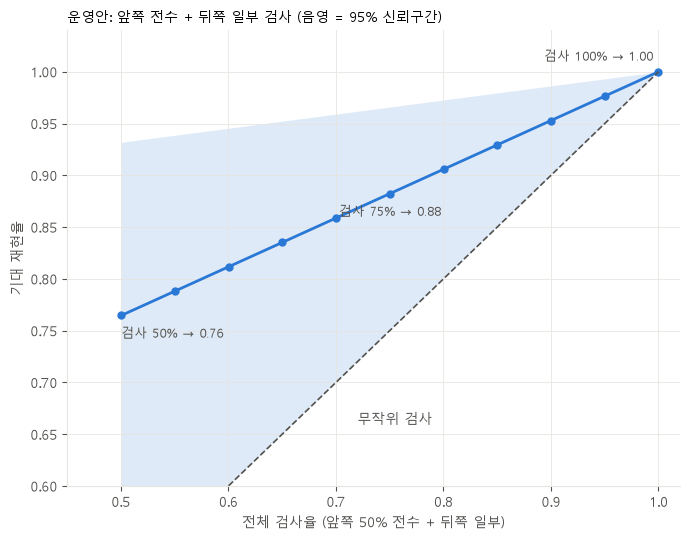

In [63]:
fig, ax = plt.subplots(figsize=(7, 5.5))
x_all = plan['전체 검사율']
ax.fill_between(x_all, plan['기대 재현율 하한(95%)'], np.minimum(ci.high + back_frac * (1 - ci.high), 1),
                color=C_MAIN, alpha=0.15, linewidth=0)
ax.plot(x_all, plan['기대 재현율'], color=C_MAIN, linewidth=2, marker='o', markersize=5)
ax.plot([0, 1], [0, 1], color=C_INK, linewidth=1.2, linestyle='--')
ax.text(0.72, 0.66, '무작위 검사', color=C_INK)

for b, ha, offset in [(0.0, 'left', (0, -16)), (0.5, 'center', (0, -16)), (1.0, 'right', (-4, 8))]:
    r = plan.loc[plan['뒤쪽 검사 비율'] == b].iloc[0]
    ax.annotate(f"검사 {r['전체 검사율']:.0%} → {r['기대 재현율']:.2f}", (r['전체 검사율'], r['기대 재현율']),
                xytext=offset, textcoords='offset points', ha=ha, color=C_INK, fontsize=9)

ax.set_xlabel('전체 검사율 (앞쪽 50% 전수 + 뒤쪽 일부)')
ax.set_ylabel('기대 재현율')
ax.set_xlim(0.45, 1.02); ax.set_ylim(0.6, 1.04)
ax.set_title('운영안: 앞쪽 전수 + 뒤쪽 일부 검사 (음영 = 95% 신뢰구간)', loc='left')
plt.tight_layout()
plt.show()

### 7-5. 정리

| 항목 | 결과 | 해석 |
|---|---|---|
| 위험 점수 (7-1) | 앞쪽 부품 계수 0.87 (50개 fold 모두 같은 부호), IF 이상 점수 계수 0.02 (같은 부호 64% < 기준 95%) | 이상 점수는 기여 없음 → 기준에 따라 **쌍 순서 규칙**을 최종 점수로 채택 |
| 재현율 1.0 목표 (7-2) | 쌍 순서 규칙: 검사 100%, 목표 달성 fold 100%. 뒤쪽 무작위 / 로지스틱: 검사 90% / 92%, 목표 달성 fold 82% / 64% | 임계값을 정할 때 쓰지 않은 샷에서 재현율 1.0을 지키려면 **사실상 전수검사** |
| 재현율 0.92 목표 (7-2) | 쌍 순서 규칙: 검사 100% (학습 fold 불량 13~14개 중 앞쪽만으로 92%를 못 채워 임계값이 뒤쪽까지 내려감). 뒤쪽 무작위·로지스틱: 검사 71~76%, 목표 달성 fold 48~56% | 불량 17개로 정한 임계값은 fold마다 크게 흔들린다 |
| 시간 순 검증 (7-3) | 평가 구간 2~5의 불량 0개 → 재현율 정의 불가 | 미래 구간 적용성은 확인할 수 없다 |
| 운영안 (7-4) | 앞쪽만 검사(50%) → 기대 재현율 0.76 (95% 하한 0.50) / 뒤쪽 절반 추가(75%) → 0.88 / 전수(100%) → 1.00 | 앞쪽 불량 비율의 신뢰구간이 넓어(50~93%) 운영안의 불확실성이 크다 |

**CN7 결론 (섹션 7, 해석 A 가정)**
- 쌍 순서 규칙이 최종 점수로 채택되지만 RG3보다 약하다 (검사 50% → 재현율 0.76, RG3 0.92).
- 재현율 1.0이 필수라면 전수검사.
- 이 섹션은 RG3 설계(쌍 순서 + IF-A 결합)를 그대로 따른 결과다. 공정 값 지도학습·설정 B는 후보에 없으며, 이들의 높은 성능은 시기 효과와 겹친다 (8-2 b-2).

# 8. 결과 분석

과제의 마지막 요구 — **모델이 어떤 조건에서 작동하고 어떤 조건에서 실패하는가** — 에 답하고, 보고서에 옮길 결론을 정리한다.

- **8-1** 종합 성능 비교 (표 + 포착 곡선)
- **8-2** 작동·실패 조건: (a) 부품 위치 (b) 시간 구간 (c) 공정 조건 (d) 실패 원인 정리 (e) 분석의 한계
- **8-3** ROI 입력 정리 (식은 추후)
- **8-4** 결론과 제언

### 8-1. 종합 성능 비교

섹션 5~7의 모든 방법을 같은 기준(샷 단위 부트스트랩 95% 구간)으로 한 표에 모은다. 최종 채택은 7-1의 `FINAL_SCORE`.

> 쌍 순서 규칙의 방향은 evalset에서 찾은 것이라 이 표의 값은 낙관적일 수 있다. 공정한 값은 교차검증(7-1·7-2, 아래 팀 지표 표)과 시간 순 검증(7-3)이다.

In [64]:
KEY = ['검사율@재현율1', '검사율@재현율0.92', '재현율@50%', 'PR-AUC', 'ROC-AUC']
summary = pd.DataFrame({name: res['값'] for name, res in all_res.items()}).T[KEY]
summary.insert(1, '검사율@재현율1 95% 구간',
               [f"{r.loc['검사율@재현율1', '95% 하한']:.2f}~{r.loc['검사율@재현율1', '95% 상한']:.2f}" for r in all_res.values()])
summary.round(3)

,검사율@재현율1,검사율@재현율1 95% 구간,검사율@재현율0.92,재현율@50%,PR-AUC,ROC-AUC
무작위,0.946,0.69~1.00,0.898,0.498,0.019,0.498
쌍 순서 규칙,0.893,0.56~1.00,0.790,0.765,0.029,0.637
IF (A: train 학습),0.976,0.85~0.99,0.968,0.588,0.020,0.513
IF (B: 평가 구간 학습),0.301,0.26~0.34,0.298,1.000,0.218,0.889
AE (A: train 학습),0.950,0.62~0.97,0.734,0.647,0.035,0.649


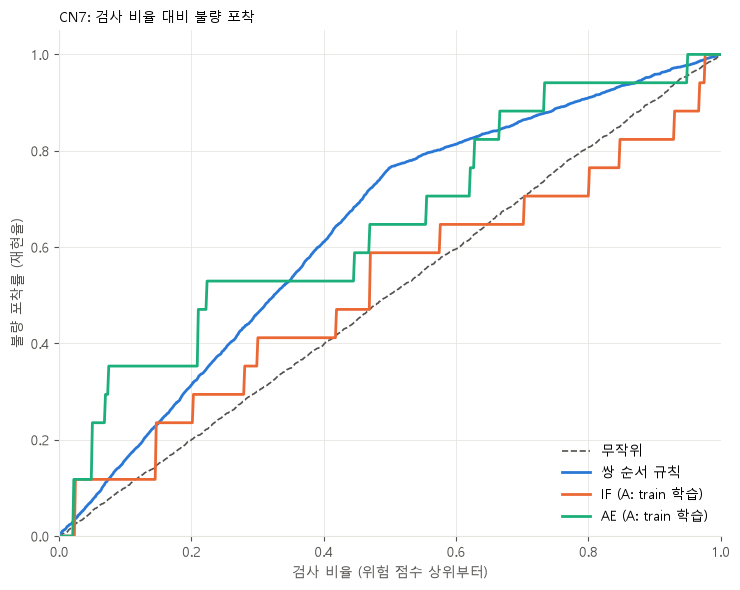

In [65]:
C_AQUA = '#1baf7a'
curve_specs = [  # (이름, 점수 함수, 색, 선 모양)
    ('무작위', baselines['무작위'], C_INK, '--'),
    ('쌍 순서 규칙', baselines['쌍 순서 규칙'], C_MAIN, '-'),
    ('IF (A: train 학습)', lambda rng: scores['IF (A: train 학습)'], C_SUB, '-'),
    ('AE (A: train 학습)', lambda rng: scores['AE (A: train 학습)'], C_AQUA, '-'),
]

fig, ax = plt.subplots(figsize=(7.5, 6))
for name, fn, color, ls in curve_specs:
    x, y = capture_curve(fn)
    ax.plot(x, y, color=color, linestyle=ls, linewidth=2 if ls == '-' else 1.2, label=name)
ax.set_xlabel('검사 비율 (위험 점수 상위부터)')
ax.set_ylabel('불량 포착률 (재현율)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', frameon=False)
ax.set_title('CN7: 검사 비율 대비 불량 포착', loc='left')
plt.tight_layout()
plt.show()

#### 팀 평가 지표: F1 · Recall · PR-AUC

F1·Recall은 **임계값**이 있어야 계산되므로 7-2와 같은 방식으로 정한다.
- 교차검증의 학습 fold에서 **F1이 최대가 되는 임계값**을 정하고, 평가 fold에 적용해 F1·Recall을 잰다 (50개 fold 평균 ± 표준편차).
- PR-AUC는 평가 fold에서 임계값 없이 계산한다 (동점은 8-1과 같이 무작위 줄세우기). fold당 불량이 3~4개뿐이라 8-1(전체 평가)보다 값이 크고 흔들림이 크므로, **같은 표의 `무작위` 행과 비교**한다.
- 참고: Precision, 불량 판정 비율(= 검사율).

In [66]:
def f1_threshold(score, y):
    """F1이 최대가 되는 임계값 (이 값 이상이면 불량으로 판정)"""
    prec, rec, thr = precision_recall_curve(y, score)
    f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    return thr[np.argmax(f1)]


rng = np.random.default_rng(SEED)
rows = []
for tr, te in cv_splits:
    candidates = {'무작위': rng.random(len(y_eval)), '쌍 순서 규칙': front, **scores}
    y_te = y_eval[te]
    for name, s in candidates.items():
        pred = s[te] >= f1_threshold(s[tr], y_eval[tr])
        order = np.lexsort((rng.random(len(te)), -s[te]))   # 동점은 무작위 순서
        rank_score = np.empty(len(te))
        rank_score[order] = np.arange(len(te), 0, -1)
        rows.append({'모델': name,
                     'F1': f1_score(y_te, pred),
                     'Recall': recall_score(y_te, pred),
                     'PR-AUC': average_precision_score(y_te, rank_score),
                     'Precision': precision_score(y_te, pred, zero_division=0),
                     '불량 판정 비율': pred.mean()})

team_cv = pd.DataFrame(rows)
team_mean = team_cv.groupby('모델', sort=False).mean()
team_std = team_cv.groupby('모델', sort=False).std()
team_tbl = team_mean.combine(team_std, lambda m, s: m.map('{:.3f}'.format) + ' ± ' + s.map('{:.3f}'.format))
team_tbl

,F1,Recall,PR-AUC,Precision,불량 판정 비율
모델,,,,,
무작위,0.035 ± 0.058,0.298 ± 0.355,0.039 ± 0.036,0.024 ± 0.055,0.277 ± 0.303
쌍 순서 규칙,0.042 ± 0.008,0.778 ± 0.190,0.038 ± 0.049,0.021 ± 0.004,0.500 ± 0.001
IF (A: train 학습),0.008 ± 0.016,0.133 ± 0.288,0.059 ± 0.095,0.004 ± 0.008,0.127 ± 0.233
IF (B: 평가 구간 학습),0.273 ± 0.299,0.260 ± 0.278,0.330 ± 0.268,0.310 ± 0.372,0.010 ± 0.007
AE (A: train 학습),0.040 ± 0.079,0.127 ± 0.253,0.078 ± 0.089,0.024 ± 0.047,0.058 ± 0.023


### 8-2. 작동·실패 조건

#### (a) 부품 위치

In [67]:
pos_tbl = evalset.groupby('pair_pos').agg(부품=(TARGET, 'size'), 불량=(TARGET, 'sum'), 불량률=(TARGET, 'mean'))
pos_tbl.index = ['앞쪽 (pair_pos=0)', '뒤쪽 (pair_pos=1)']
pos_tbl['전체 불량 중 비율'] = pos_tbl['불량'] / pos_tbl['불량'].sum()
pos_tbl['쌍 순서 규칙(앞쪽 검사)'] = ['포착', '놓침']
pos_tbl.round(3)

,부품,불량,불량률,전체 불량 중 비율,쌍 순서 규칙(앞쪽 검사)
앞쪽 (pair_pos=0),606,13,0.021,0.765,포착
뒤쪽 (pair_pos=1),605,4,0.007,0.235,놓침


→ 앞쪽 부품의 불량률(2.1%)이 뒤쪽(0.7%)의 약 3배이지만, 뒤쪽 불량도 4개(24%)로 RG3(2개, 8%)보다 많다.
뒤쪽 불량은 샷 40(뒤쪽만 불량)과 샷 58·59·60(두 부품 모두 불량)이다. 연속 불량 구간의 끝(58~60)에서는 두 부품이 함께 불량이 되어, 쌍 순서만으로는 놓친다.

#### (b) 시간 구간

평가 구간(606샷)을 5등분해 구간별 불량률과 "앞쪽만 검사" 시 재현율을 본다. 불량률 차이 검정은 샷 단위(한 샷의 두 부품은 공정 값이 같아 부품 단위로 세면 표본이 중복됨).

In [68]:
block = pd.qcut(evalset['shot_id'], 5, labels=[f'{i}구간' for i in range(1, 6)])
tmp = evalset.assign(구간=block, 앞쪽_불량=(evalset['pair_pos'].eq(0) & evalset[TARGET].eq(1)).astype(int))
time_tbl = tmp.groupby('구간', observed=True).agg(
    샷_시작=('shot_id', 'min'), 샷_끝=('shot_id', 'max'),
    부품=(TARGET, 'size'), 불량=(TARGET, 'sum'), 앞쪽_불량=('앞쪽_불량', 'sum'),
)
time_tbl['불량률'] = time_tbl['불량'] / time_tbl['부품']
time_tbl['앞쪽만 검사 시 재현율'] = time_tbl['앞쪽_불량'] / time_tbl['불량']

shot_block = pd.qcut(shots.index.to_series(), 5, labels=time_tbl.index)
print('구간별 불량률 차이 (샷 단위 카이제곱) p =', round(chi2_contingency(pd.crosstab(shot_block, shots[TARGET]))[1], 3))
print('뒤쪽 불량이 나온 샷:', evalset.loc[(evalset['pair_pos'] == 1) & (evalset[TARGET] == 1), 'shot_id'].tolist())
time_tbl.round(3)

구간별 불량률 차이 (샷 단위 카이제곱) p = 0.0
뒤쪽 불량이 나온 샷: [40, 58, 59, 60]


,샷_시작,샷_끝,부품,불량,앞쪽_불량,불량률,앞쪽만 검사 시 재현율
구간,,,,,,,
1구간,0,121,243,17,13,0.07,0.765
2구간,122,242,242,0,0,0.00,NaN
3구간,243,363,242,0,0,0.00,NaN
4구간,364,484,242,0,0,0.00,NaN
5구간,485,605,242,0,0,0.00,NaN


#### (b-2) 시기 효과 확인

불량이 모두 앞쪽 샷에 몰려 있으므로, 공정 값의 높은 구분력(6-4·6-6)이 **개별 불량**을 가리키는지 **불량이 몰린 시기**를 가리키는지 확인한다.
- **시기 구분**: 공정 값으로 "첫 샷 ~ 마지막 불량 샷"과 그 이후 샷을 구분할 수 있는지 (5-1과 같은 `shot_id` 묶음 교차검증)
- **불량 시기 안**: 그 시기의 부품만으로 불량 vs 양품을 다시 구분 (같은 방식의 교차검증)
- **비교 기준**: 샷 순서 하나만 점수로 쓴 경우 (전체: 이른 샷일수록 위험 / 불량 시기 안: 늦은 샷일수록 위험)

In [69]:
sid = evalset['shot_id'].values
last_ng = sid[y_eval == 1].max()   # 마지막 불량 샷
early = sid <= last_ng             # 불량이 나온 시기
print(f'샷 0~{last_ng}: 부품 {early.sum()}, 불량 {y_eval[early].sum()} / 샷 {last_ng + 1}~: 부품 {(~early).sum()}, 불량 {y_eval[~early].sum()}')


def group_splits(X, y, g):
    """5-1과 같은 분할: shot_id 묶음, 층화 5-fold × 10회"""
    return [(tr, te) for r in range(N_REPEATS)
            for tr, te in StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + r).split(X, y, g)]


# 시기 구분: 공정 값으로 불량 시기 vs 이후 샷
y_period = early.astype(int)
print('공정 값으로 시기 구분 (로지스틱 ROC-AUC):', round(cv_auc(make_lr, X_eval_A, y_period, group_splits(X_eval_A, y_period, groups)), 3))
ks_period = pd.Series({c: ks_2samp(evalset.loc[early, c], evalset.loc[~early, c]).statistic for c in FEATS})
print('시기 간 KS 상위:', ks_period.nlargest(5).round(2).to_dict())

# 불량 vs 양품: 전체 기간 vs 불량 시기 안
Xw, yw = X_eval_A[early], y_eval[early]
w_splits = group_splits(Xw, yw, groups[early])
if_b = scores['IF (B: 평가 구간 학습)']
period_tbl = pd.DataFrame({
    '전체 기간': {
        '지도학습: 로지스틱': sup_tbl.loc['지도학습: 로지스틱 (공정 값 23개)', '교차검증 ROC-AUC'],
        '지도학습: 랜덤포레스트': sup_tbl.loc['지도학습: 랜덤포레스트 (공정 값 23개)', '교차검증 ROC-AUC'],
        'IF (B: 평가 구간 학습)': roc_auc_score(y_eval, if_b),
        '샷 순서만': roc_auc_score(y_eval, -sid),
    },
    f'불량 시기 안 (샷 0~{last_ng})': {
        '지도학습: 로지스틱': cv_auc(make_lr, Xw, yw, w_splits),
        '지도학습: 랜덤포레스트': cv_auc(make_rf, Xw, yw, w_splits),
        'IF (B: 평가 구간 학습)': roc_auc_score(yw, if_b[early]),
        '샷 순서만': roc_auc_score(yw, sid[early]),
    },
})
period_tbl.rename_axis('ROC-AUC (불량 vs 양품)').round(3)

샷 0~60: 부품 121, 불량 17 / 샷 61~: 부품 1090, 불량 0


공정 값으로 시기 구분 (로지스틱 ROC-AUC): 0.983
시기 간 KS 상위: {'Plasticizing_Position': 0.77, 'Mold_Temperature_3': 0.77, 'Mold_Temperature_4': 0.77, 'Plasticizing_Time': 0.74, 'Max_Back_Pressure': 0.74}


,전체 기간,불량 시기 안 (샷 0~60)
ROC-AUC (불량 vs 양품),,
지도학습: 로지스틱,0.949,0.628
지도학습: 랜덤포레스트,0.962,0.802
IF (B: 평가 구간 학습),0.889,0.642
샷 순서만,0.919,0.930


→ 불량 17개 전부가 1구간, 그중에서도 **샷 24~60**에 있다 (구간별 불량률 차이 p < 0.001). 쌍 순서 규칙의 재현율도 1구간에서만 정의된다.

**시기 효과 확인 (b-2)**
- **샷 순서 하나만** 점수로 써도(이른 샷일수록 위험) ROC-AUC 0.92 — 공정 값 모델과 비슷한 수준이다.
- 공정 값으로 **불량 시기(샷 0~60)와 이후 샷을 구분**하면 ROC-AUC 0.98 — 그 시기의 공정 조건이 나머지와 뚜렷이 다르다 (KS 상위: Plasticizing_Position·Mold_Temperature_3·4 0.77, Plasticizing_Time·Max_Back_Pressure 0.74).
- **불량 시기 안에서만** 보면(121부품, 불량 17) 로지스틱 0.63, 랜덤포레스트 0.80, IF-B 0.64로 떨어지고, 이 안에서도 샷 순서(늦을수록 위험) 0.93이 가장 높다.

→ 전체 기간의 높은 구분력(지도학습 0.95~0.96, IF-B 0.89)은 대부분 **"불량이 몰린 시기"와 나머지 시기의 공정 차이**로 설명된다. 개별 불량을 공정 값으로 예측한다는 근거로는 약하다.
불량 시기 안의 랜덤포레스트 0.80도 샷 순서(불량이 구간 끝에 몰림)와 분리되지 않는다.

#### (c) 공정 조건

공정 값을 각각 4구간(4분위)으로 나눠 구간별 불량률이 다른지 샷 단위로 검정한다 (다중검정 보정 q). 평가 구간에서 값이 적어 구간을 나눌 수 없는 피처는 자동 제외된다.

In [70]:
rows = []
for c in FEATS:
    bins = pd.qcut(shots[c], 4, duplicates='drop')
    if bins.nunique() < 2:
        continue
    tab = pd.crosstab(bins, shots[TARGET])
    rate = tab[1] / tab.sum(axis=1)
    rows.append({'피처': c, '구간 수': bins.nunique(), '최저 불량률': rate.min(), '최고 불량률': rate.max(),
                 'p': chi2_contingency(tab)[1]})
cond_tbl = pd.DataFrame(rows).set_index('피처')
cond_tbl['q'] = false_discovery_control(cond_tbl['p'])
print('q < 0.05인 피처 수:', (cond_tbl['q'] < 0.05).sum(), '/', len(cond_tbl))
cond_tbl.sort_values('p').round(3).head(10)

q < 0.05인 피처 수: 10 / 23


,구간 수,최저 불량률,최고 불량률,p,q
피처,,,,,
Mold_Temperature_3,4,0.000,0.088,0.000,0.000
Mold_Temperature_4,4,0.000,0.088,0.000,0.000
Average_Back_Pressure,4,0.000,0.062,0.000,0.001
Plasticizing_Time,4,0.000,0.062,0.000,0.002
Filling_Time,4,0.000,0.073,0.000,0.002
Plasticizing_Position,4,0.000,0.061,0.001,0.002
Max_Back_Pressure,4,0.000,0.057,0.002,0.006
Injection_Time,4,0.000,0.069,0.005,0.013
Clamp_Close_Time,2,0.020,0.200,0.007,0.018


→ 23개 중 **10개 피처**에서 구간별 불량률이 유의하게 다르다 (q < 0.05). Mold_Temperature_3·4가 가장 강하다 (구간별 0~8.8%). 대부분 최저 구간의 불량률이 0이라 "특정 값 범위에서만 불량"처럼 보이지만,
(b-2)대로 이 값 범위는 **불량이 몰린 시기의 공정 조건**과 겹친다. 즉 불량이 집중되는 공정 조건 = 불량이 집중된 시기의 공정 조건이며, 둘을 이 데이터로 분리할 수 없다.

#### (d) 작동·실패 원인 정리

| 원인 | 근거 | 섹션 |
|---|---|---|
| **불량이 한 시기에 몰림** (핵심) | 불량 샷 14개 모두 샷 24~60, 이후 1,090부품 불량 0. 샷 순서만으로 ROC-AUC 0.92 | 4-4, 8-2 (b) |
| 그 시기의 공정 조건이 다름 | 공정 값으로 불량 시기/이후 구분 ROC-AUC 0.98. 라벨을 ±3샷 옮겨도 신호 유지 | 4-3, 8-2 (b-2) |
| → 공정 값 모델이 "작동"하는 이유 | 지도학습 0.95~0.96, IF-B 0.89는 시기 구분과 겹침. 불량 시기 안에서는 0.63~0.80으로 하락하고 샷 순서(0.93)를 넘지 못함 | 6-4, 6-6, 8-2 (b-2) |
| 설정 A(과거 unlabeled 학습) 실패 | IF-A 0.51, 평가 불량/양품 점수 비 1.00: 불량 시기의 공정 조건이 과거 정상 패턴에서 특별히 벗어나지 않음 | 6-4 |
| 쌍 순서 신호 약함 | 13/17 (p = 0.049), 앞쪽 불량 비율 95% 신뢰구간 50~93%. 연속 불량 끝(샷 58~60)은 두 부품 모두 불량 | 4-2, 7-4, 8-2 (a) |
| 적은 불량 수 | 불량 17개(샷 14개), fold당 3~4개. 재현율 목표 달성 fold 48~82%로 흔들림 | 7-2 |

#### (e) 분석의 한계

| 한계 | 내용 | 영향 |
|---|---|---|
| **쌍 순서의 의미 미확인** | 해석 A(부품 위치)를 가정. 제품명·시각 열이 없어 직접 확인 불가하고, 다른 금형인 RG3도 불량이 앞쪽에 치우쳐(23/25) 해석 B(검사 결과 기록 순서 = 정답 누수)를 배제하지 못함 | 해석 B라면 쌍 순서 규칙·운영안은 사용 불가 |
| **시기 효과와 불량 신호의 혼재** | 불량이 한 시기에만 있어 공정 값의 구분력을 시기 차이와 분리할 수 없고, 시간 순 검증(7-3)도 불가 | 공정 값 모델의 성능(ROC-AUC 0.95)을 미래 샷에 대한 예측력으로 보고하면 과대평가 위험 |
| 단일 기간·단일 운전 조건 | 평가 데이터는 606샷(한 기간), labeled 전부가 운전 조건 1개(3-6) | 다른 기간·운전 조건에서의 성능은 알 수 없음 |
| 적은 불량 수 | 불량 17개(샷 14개), 뒤쪽 불량 4개 | 모든 추정의 신뢰구간이 넓다 |

### 8-3. ROI 입력 정리 (식은 추후 반영)

| 입력 | 값 / 위치 |
|---|---|
| 운영안별 전체 검사율·기대 재현율 | `plan` (7-4) |
| 불량률 | 1.4% (부품 단위, 17 / 1,211) |
| 기대 재현율 불확실성 | 앞쪽 불량 비율 95% 신뢰구간 (`ci`) |
| 필요 비용 항목 | 검사 1회 비용, 불량 유출 1건 비용, 생산량 → **팀 ROI 식 수령 후 입력** |

> ROI 식을 받으면 이 자리에 운영안별 절감액 계산 셀을 추가한다. `plan`의 기대 재현율은 **해석 A(3-7)가 맞을 때만** 유효하다.
> 주의: CN7은 불량이 한 시기에 몰려 있어 불량률 1.4%를 평소 불량률로 보기 어렵다 (불량 시기 샷 0~60: 17/121 = 14%, 이후: 0/1,090).

### 8-4. 결론과 제언

**CN7 결론 — 해석 A (쌍 순서 = 부품 위치)일 때**
1. **공정 값의 높은 구분력은 대부분 "불량 시기"를 가리킨다**: 공정 값 지도학습 ROC-AUC 0.95~0.96, IF-B 0.89로 강해 보이지만, 불량 17개가 모두 샷 24~60에 몰려 있고 그 시기의 공정 조건이 나머지와 다르다 (시기 구분 0.98, 샷 순서만으로 0.92). 불량 시기 안에서는 0.63~0.80으로 떨어진다 → "불량이 나는 공정 시기를 알아보는 것"은 가능하지만 "개별 불량 예측"의 근거는 약하다.
2. **쌍 순서 규칙은 RG3보다 약하다**: 검사 50%로 불량 76% (이항검정 p = 0.049, RG3 92%). 연속 불량 끝(샷 58~60)은 두 부품이 모두 불량이다.
3. **재현율 1.0이 필수라면 전수검사**: 검사를 줄인 방식은 목표 달성 fold가 64~82%에 그친다 (7-2).
4. **미래 적용성은 확인 불가**: 불량 시기 이후 불량이 없어 시간 순 검증이 성립하지 않는다 (7-3).

**해석 B (쌍 순서 = 검사 결과 기록 순서)일 때**
- 쌍 순서는 사용할 수 없고 결론 2·운영안(7-4)은 무효. 결론 1(공정 값 신호 = 시기 효과)은 쌍 순서와 무관하므로 그대로다.

**RG3 비교 (핵심)**

| 항목 | RG3 | CN7 |
|---|---|---|
| 불량 수 / 불량률 | 25 / 2.1% | 17 / 1.4% |
| 불량의 시간 분포 | 고르게 흩어짐 (평균 간격 20.8샷, 균등하면 23.6샷) | 샷 24~60에 몰림 (평균 간격 2.8샷, 균등하면 43.3샷) |
| 공정 값 불량 vs 양품 (q < 0.05인 피처) | 0개 | 13개 |
| 공정 값 지도학습 ROC-AUC | 0.48~0.51 | 0.95~0.96 (불량 시기 안: 0.63~0.80) |
| IF 설정 B ROC-AUC | 무작위 수준 | 0.89 |
| 쌍 순서 (앞쪽 불량) | 23/25 (p = 1.9e-05) | 13/17 (p = 0.049) |
| 두 부품 모두 불량인 샷 | 0 | 3 |
| labeled가 unlabeled에 들어 있는 행 | 774 / 1,182 | 1,211 / 1,211 |

→ **CN7에서는 예측되고 RG3에서는 실패하는 이유는 모델이 아니라 불량이 발생한 방식의 차이다.** CN7 불량은 공정 조건이 달랐던 한 시기에 몰려 있어 공정 값이 그 시기를 가리키고, RG3 불량은 시기·공정 조건과 무관하게 흩어져 있어 공정 값이 가리킬 것이 없다.
따라서 CN7의 높은 ROC-AUC를 "CN7 공정 값에는 불량 정보가 있다"로 보고하면 과대해석이다.

**결정이 필요한 것**
- 시기 효과 처리: 불량 시기(샷 0~60) 안 분석을 주 평가로 둘지, 전체 기간 평가를 유지하고 한계로 명시할지
- 섹션 7 후보에 공정 값 지도학습·IF 설정 B를 추가할지
- 재현율 보조 목표 0.92 유지 여부 (CN7에서는 불량 17개 중 16개)

**가장 먼저 할 일**: KAMP 원본 1차 가공 데이터(`labeled_data.csv`)의 `TimeStamp`로 샷 24~60이 어떤 시기인지(가동 초기, 조건 변경 직후 등) 확인하고, `PART_NAME`으로 쌍 순서 해석을 RG3와 함께 확정한다.

**현장 조치 제언 (가설 수준)**
- 불량 시기에 달랐던 공정 조건(Plasticizing_Position, Mold_Temperature_3·4, Plasticizing_Time, Max_Back_Pressure) 점검: 이 조건들이 평소와 달라지는 시기를 감지해 그 시기에만 검사를 강화하는 운영이 CN7 데이터 구조에 맞는다.
- 쌍 순서를 쓸 경우(해석 A) 앞쪽 부품 우선 검사, 뒤쪽은 ROI에 맞춘 표본 검사.

**데이터 수집 제언**
- 시각(`TimeStamp`)·제품명(LH/RH) 열 유지 → 시기와 부품 위치를 추정이 아닌 사실로 사용.
- 불량 시기가 여러 번 포함된 기간의 라벨 데이터 → 시기 효과와 불량 신호를 분리할 수 있다.
- 불량 유형(`Reason`) 라벨 → 연속 불량(샷 50~60)의 원인 분석.